# EXP-20260828-05 E2E — Stepwise Grounding v2

```text
기준 원본: EXP-20260828-05_E2E.ipynb
생성 기준일: 2026-08-28
목적: 최종안의 13개 노드를 단계별로 추가·검증할 수 있는 실험 노트북
```

핵심 변경점은 세 가지다.

1. `validate_plan`에서는 더 이상 RDB 물리 컬럼/SQL compile을 하지 않는다.
2. 물리 컬럼 확정은 `rdb_ground`에서만 수행한다.
3. `generate_sql → validate_sql(AST + whitelist + dry-run + 최대 1회 repair) → execute_plan`을 분리한다.

원본 `%%module` 셀은 보존한다. 아래의 `*_v2` 모듈이 새 파이프라인이며, 각 노드 셀 직후 독립 테스트 셀이 있다.


### local DB 연결 설정

In [ ]:
import psycopg

conn = psycopg.connect(
    host="127.0.0.1",
    port=5432,
    user="postgres",
    password="postgres",
    dbname="mafest",
)

with conn.cursor() as cur:
    cur.execute("SELECT current_database(), version();")
    print(cur.fetchone())

# conn.close()

('mafest', 'PostgreSQL 18.6 (Ubuntu 18.6-0ubuntu0.26.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 15.2.0-16ubuntu1) 15.2.0, 64-bit')


In [ ]:
# table 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """)
    print([row[0] for row in cur.fetchall()])

# 데이터와 벡터 컬럼을 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name, column_name, data_type
        FROM information_schema.columns
        WHERE table_name IN ('bond_schema_terms', 'schema_terms_all')
        ORDER BY table_name, ordinal_position;
    """)
    for row in cur.fetchall():
        print(row)

['bond_schema_terms', 'schema_terms_all']
('bond_schema_terms', 'term_uri', 'text')
('bond_schema_terms', 'label', 'text')
('bond_schema_terms', 'comment', 'text')
('bond_schema_terms', 'alt_labels', 'ARRAY')
('bond_schema_terms', 'content', 'text')
('bond_schema_terms', 'embedding', 'USER-DEFINED')
('schema_terms_all', 'term_uri', 'text')
('schema_terms_all', 'label', 'text')
('schema_terms_all', 'comment', 'text')
('schema_terms_all', 'alt_labels', 'ARRAY')
('schema_terms_all', 'content', 'text')
('schema_terms_all', 'embedding', 'USER-DEFINED')


# Agent Test

- Agent 로직 테스트

```text
src/agent/nodes.py
  ↓ 노드 함수 정의
src/agent/agent_core.py
  ↓ 노드 연결 및 LangGraph 생성
테스트 스크립트 또는 Jupyter
  ↓ ask(question) 실행
결과 확인
```
-  shell 테스트 
```shell
python -c "import sys; sys.path.insert(0, 'src'); from agent.agent_core import ask; print(ask('KODEX 200의 공식 상품명과 상품 코드를 알려줘'))"
```
- test 스크립트
```shell
python script/test_bond_agent.py
```
```shell
python script/test_rdb_vertical_slice.py
```
- Jupyter에서는 다음처럼 실행
```python
from agent.agent_core import ask

result = ask("KODEX 200의 공식 상품명과 상품 코드를 알려줘")
result
```

### Module 등록 코드

In [1]:
# === 셀 매직 정의: 각 셀을 실제 모듈로 등록한다 ===
# Jupyter Notebook의 셀 내용을 실제 Python 모듈처럼 등록해 주는 %%module 셀 매직을 정의
# 사용법: 셀 첫 줄에 `%%module <모듈명> <src 기준 경로>`.
# 셀을 수정하고 재실행하면 sys.modules 가 교체되므로, 그 모듈을 import 하는 하위 셀들을 다시 실행하면 수정본이 반영된다.
import json as _json
import sys as _sys
import types as _types
from pathlib import Path

from IPython.core.magic import register_cell_magic

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())


@register_cell_magic("module")
def _module_magic(line, cell):
    """
    %%module <모듈명> <src 기준 경로>
    셀 내용을 실제 Python 모듈처럼 등록
    예) 
    %%module agent.nodes agent/nodes.py
    VALUE = 10
    def hello():
        return VALUE

    from agent.nodes import hello
    hello()  # 10
    
    """
    name, relpath = line.split()

    # 실제 파일을 import하는 대신 메모리상 모듈 객체 생성
    mod = _types.ModuleType(name)
    mod.__file__ = str(REPO_ROOT / "src" / relpath) # 실제 소스 파일이 있을 것으로 간주하는 경로
    _sys.modules[name] = mod

    # 부모 패키지 등록 (agent.nodes -> agent)
    ## 파일 시스템에 실제 __init__.py가 없어도 namespace package처럼 동작하도록 구성
    parts = name.split(".")
    for i in range(1, len(parts)):
        pkg = ".".join(parts[:i])
        parent = _sys.modules.setdefault(pkg, _types.ModuleType(pkg))
        setattr(parent, parts[i], _sys.modules.get(name) if i == len(parts) - 1 else _sys.modules.setdefault(".".join(parts[:i + 1]), _types.ModuleType(".".join(parts[:i + 1]))))
    
    # 셀 코드 실행
    ##  셀 문자열을 Python 코드로 컴파일한 뒤, 새로 만든 모듈의 namespace에서 실행
    ##  셀 안에서 정의한 변수와 함수가 모두 해당 모듈의 멤버가 됨
    exec(
        compile(cell, mod.__file__, "exec"), 
        mod.__dict__)
    print(f"registered: {name}")




man_path = REPO_ROOT / "artifacts" / "oxigraph" / "manifest.json"
man = _json.loads(man_path.read_text(encoding="utf-8"))
assert man["cutoff"] == "2026-08-24", (
    f"store cutoff={man['cutoff']} — 2026-08-24 재빌드 필요 "
    "(kb.build_graph 의 CUTOFF 를 08-24 로 바꿔 build(); 기존 store 는 백업 후)")
print("store:", f"{man['triple_count']:,} triples, cutoff", man["cutoff"],
      "| excluded_future:", man["excluded_future_nodes"])

store: 1,628,311 triples, cutoff 2026-08-24 | excluded_future: 0


## `src/config.py`

In [ ]:
%%module config config.py


# -*- coding: utf-8 -*-
"""경로·모델 상수. 채권 MVP 범위."""
from pathlib import Path

## 저장소 루트 ==========================================================
# config.py 는 src/ 안에 있다. .parent = src/, 한 번 더 올려야 저장소 루트다.

ROOT = Path(__file__).resolve().parent.parent

## 온톨로지 ==========================================================
# 지시서는 ontology/bond.ttl 하나를 가정하지만 이 저장소의 스키마는 common + 도메인 4로 갈려 있다.
# 테스트 질문의 '위험등급'(fp:RiskGrade·fp:riskGradeLevel)은 common.ttl에만 있어서
# bond_kr.ttl만 인덱싱하면 4문항 중 1문항을 못 답한다. 둘 다 넣는다.
BOND_TTL_PATHS = [ROOT / "ontology" / "bond_kr.ttl", ROOT / "ontology" / "common.ttl"]

## 데이터·산출물 ==========================================================
# 한 번만 올리면 ARTIFACTS 가 src/artifacts 를 새로 만듦
ARTIFACTS = ROOT / "artifacts"

## 데이터베이스·모델 ==========================================================
# 스키마 벡터 인덱스는 PostgreSQL + pgvector 에 둔다
# 비밀번호를 포함하므로 DSN 을 로그에 찍지 않는다. 접속 정보는 환경변수로 덮을 수 있다.
import os

BOND_DB = {
    "host": os.environ.get("PGHOST", "127.0.0.1"),
    "port": os.environ.get("PGPORT", "5432"),
    "user": os.environ.get("PGUSER", "postgres"),
    "password": os.environ.get("PGPASSWORD", "postgres"),
    "dbname": os.environ.get("PGDATABASE", "mafest"),
}

# 유닉스 소켓은 peer 인증에 걸린다. host 를 명시해 TCP 로 붙는다.
BOND_DSN = " ".join(f"{k}={v}" for k, v in BOND_DB.items())
BOND_TABLE = "bond_schema_terms"
EMBED_DIM = 1024
BOND_TOP_K = 5
# cosine 점수 하한. 실측상 0.36~0.38대는 무관한 용어(자회사 관계 등)가 섞인다.
# 빈약한 근거를 주면 모델이 일반 지식으로 메워 근거 없는 단정이 나온다.
BOND_SCORE_FLOOR = 0.45
EMBEDDING_MODEL = "bge-m3"        # 1024차원, cosine (CLOVA Studio)


## 모델 선택. HCX-005·HCX-DASH-002·HCX-007 비교=========================================
# 1단계 Query Frame 추출
# 근거: vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md
FRAME_MODEL = "HCX-007"
ANSWER_MODEL = "HCX-005"          # 답변 생성
CHAT_TIMEOUT_SECONDS = 13         # API tail stall은 재시도 없이 ABSTAIN해 15초 E2E를 지킨다
CLOVA_HOST = "https://clovastudio.stream.ntruss.com"


# Azure Data API  =========================================
# 현재 공개 테스트 API는 임시 주소다. 운영에서는 환경변수로 반드시 덮어쓴다.
FINANCIAL_DATA_API_URL = os.environ.get(
    "FINANCIAL_DATA_API_URL",
    "http://40.82.145.44:8000",
)
FINANCIAL_DATA_RELEASE_ID = os.environ.get(
    "FINANCIAL_DATA_RELEASE_ID",
    "financial-products-2026-08-24@"
    "ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38",
)
DATA_API_TIMEOUT_SECONDS = float(
    os.environ.get("DATA_API_TIMEOUT_SECONDS", "10")
)

registered: config


## `src/clova.py`

In [ ]:
%%module clova clova.py
# -*- coding: utf-8 -*-
"""CLOVA Studio 클라이언트 — 채팅과 임베딩.

콘솔 샘플 코드와 다른 점 셋 (실측으로 확인):
  1. Accept를 application/json 으로. text/event-stream 이면 SSE라 반환값으로 못 쓴다.
  2. 추론 모델(HCX-007)은 maxTokens 를 거부한다. maxCompletionTokens 를 쓴다
     — 값 범위 문제가 아니라 파라미터명이 다르다(maxTokens=4096도 40001).
  3. HCX-007에서 structured outputs 를 쓰려면 thinking 을 명시적으로 꺼야 한다.
     기본 ON 이라 responseFormat 과 충돌한다. "off"는 무효값이고 "none"만 받는다.
"""
import json
import sys

import requests

from config import CHAT_TIMEOUT_SECONDS, CLOVA_HOST, EMBEDDING_MODEL, ROOT

REASONING_MODELS = {"HCX-007"}


def load_key() -> str:
    """.env의 clova 키. 값은 절대 로그에 남기지 않는다."""
    env = ROOT / ".env"
    if not env.exists():
        sys.exit(f"FAIL  .env 없음: {env}")
    for line in env.read_text(encoding="utf-8").splitlines():
        k, _, v = line.partition("=")
        if k.strip() == "clova":
            key = v.strip().strip('"').strip("'")
            if not key:
                sys.exit("FAIL  .env의 clova 값이 비어 있음")
            return key if key.startswith("Bearer ") else f"Bearer {key}"
    sys.exit("FAIL  .env에 clova 항목 없음")


_KEY = None


def key() -> str:
    global _KEY
    if _KEY is None:
        _KEY = load_key()
    return _KEY


def chat(model, system, user, max_tokens=1024, response_format=None, temperature=0.1):
    body = {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": system}]},
            {"role": "user", "content": [{"type": "text", "text": user}]},
        ],
        "topP": 0.8, "temperature": temperature, "repetitionPenalty": 1.1,
        "stop": [], "seed": 0,
    }
    if model in REASONING_MODELS:
        body["maxCompletionTokens"] = max_tokens
        if response_format:
            body["thinking"] = {"effort": "none"}
    else:
        body["maxTokens"] = max_tokens
        body["topK"] = 0
        body["includeAiFilters"] = True
    if response_format:
        body["responseFormat"] = response_format

    r = requests.post(f"{CLOVA_HOST}/v3/chat-completions/{model}",
                      headers={"Authorization": key(),
                               "Content-Type": "application/json; charset=utf-8",
                               "Accept": "application/json"},
                      json=body, timeout=CHAT_TIMEOUT_SECONDS)
    if r.status_code != 200:
        # 본문을 삼키면 원인을 못 찾는다. 40001 메시지에 어느 파라미터인지 들어 있다.
        raise RuntimeError(f"HTTP {r.status_code} — {r.text[:220]}")
    data = r.json()
    code = (data.get("status") or {}).get("code")
    if code not in (None, "20000"):
        raise RuntimeError(f"status {code} — {(data.get('status') or {}).get('message')}")
    content = (data.get("result") or {}).get("message", {}).get("content")
    if isinstance(content, list):   # v3는 입력이 배열이라 출력도 배열로 오는 경우가 있다
        content = "".join(p.get("text", "") for p in content if isinstance(p, dict))
    if not isinstance(content, str):
        raise RuntimeError(f"content 형태 불명: {type(content)}")
    return content


def parse_json_loose(text: str) -> dict:
    """모델이 코드펜스나 설명을 붙여도 JSON 객체만 뽑는다."""
    s = text.strip()
    if s.startswith("```"):
        s = s.split("```")[1] if "```" in s[3:] else s[3:]
        s = s.removeprefix("json").strip()
    a, b = s.find("{"), s.rfind("}")
    if a == -1 or b == -1:
        raise json.JSONDecodeError("객체를 못 찾음", s, 0)
    return json.loads(s[a:b + 1])


_EMB = None


def _embedder():
    global _EMB
    if _EMB is None:
        from langchain_naver import ClovaXEmbeddings
        _EMB = ClovaXEmbeddings(model=EMBEDDING_MODEL,
                                api_key=key().removeprefix("Bearer ").strip())
    return _EMB


def _embed_raw(text: str) -> list[float]:
    """캐시를 거치지 않는 실제 API 호출. 이 함수만 embed_query를 부른다.

    embed_many가 이걸 부르고 embed는 embed_many에 위임한다. 셋 중 하나라도
    서로를 부르면 무한 재귀가 된다 — 실제로 embed_many가 embed를 부르던 시절
    캐시 미스에서 RecursionError가 났다.
    """
    return _embedder().embed_query(text)


def embed(text: str) -> list[float]:
    """단건 임베딩. embed_many에 위임해 디스크 캐시를 공유한다.

    직접 embed_query를 부르면 캐시를 지나치므로, 같은 질문이 반복될 때마다
    API를 다시 때리고 간격도 없어 연속 호출 시 429에 걸린다.
    임베딩은 같은 텍스트·모델이면 결정적이라 캐시해도 값이 달라지지 않는다.
    """
    return embed_many([text], pause=0.0, progress=False)[0]


def embed_many(texts: list[str], pause: float = 1.2, progress: bool = True) -> list[list[float]]:
    """여러 건 임베딩. 분당 쿼터가 있어 간격을 두고, 결과는 디스크에 캐시한다.

    - langchain의 embed_documents는 지연 없이 연속 호출해 429(rate exceeded)를 맞는다.
      실측상 약 60건 연속이면 차단되므로 기본 간격을 1.2s(≈50건/분)로 둔다.
    - 캐시가 없으면 중간에 실패할 때 앞서 성공한 호출이 통째로 버려진다.
      TTL 주석은 앞으로 계속 손볼 예정이라 재빌드가 반복된다.
    """
    import hashlib
    import time as _t

    from config import ARTIFACTS
    ARTIFACTS.mkdir(exist_ok=True)
    cache_path = ARTIFACTS / "embed_cache.json"
    cache = {}
    if cache_path.exists():
        try:
            cache = json.loads(cache_path.read_text(encoding="utf-8"))
        except Exception:
            cache = {}      # 깨진 캐시는 조용히 버린다. 다시 만들면 그만이다.

    def kk(t):
        return hashlib.sha1(f"{EMBEDDING_MODEL}\x00{t}".encode()).hexdigest()

    out, new_hits, api_calls = [], 0, 0
    for i, t in enumerate(texts):
        h = kk(t)
        if h in cache:
            out.append(cache[h])
            continue
        for attempt in range(7):
            try:
                v = _embed_raw(t)      # embed() 를 부르면 여기로 되돌아와 무한 재귀가 된다
                break
            except Exception as e:
                if "429" not in str(e) and "42901" not in str(e):
                    raise
                wait = min(2 ** attempt, 65)      # 분 단위 쿼터라 최대 65s까지 기다린다
                if progress:
                    print(f"  429 — {wait}s 대기 ({i+1}/{len(texts)})", flush=True)
                _t.sleep(wait)
        else:
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
            raise RuntimeError(f"429 재시도 7회 실패: {i}번째 (여기까지는 캐시에 저장됨)")
        out.append(v)
        cache[h] = v
        new_hits += 1
        api_calls += 1
        if new_hits % 20 == 0:      # 중간 저장 — 크래시해도 진행분이 남는다
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
        if progress and (i + 1) % 25 == 0:
            print(f"  {i+1}/{len(texts)}  (API 호출 {api_calls})", flush=True)
        _t.sleep(pause)

    cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
    if progress:
        print(f"  임베딩 완료 — API 호출 {api_calls}건 / 캐시 재사용 {len(texts)-api_calls}건")
    return out


if __name__ == "__main__":
    # 자기검사: embed / embed_many / _embed_raw 의 호출 고리가 닫히지 않았는지 본다.
    # 캐시 적중 경로에서는 재귀가 드러나지 않으므로 반드시 '캐시에 없는' 문장을 쓴다.
    # (실제로 embed_many 가 embed 를 부르던 시절 RecursionError 가 났고,
    #  회귀 테스트 72건이 전부 캐시 적중이라 그 버그를 못 잡았다.)
    import uuid
    probe = f"clova 자기검사 {uuid.uuid4()}"
    v = embed(probe)
    assert len(v) == 1024, f"차원 이상: {len(v)}"
    assert embed(probe) == v, "같은 문장인데 결과가 다르다 — 캐시가 안 먹는다"
    print(f"clova 자기검사 PASS — 캐시미스 경로 dim={len(v)}, 재호출 일치")


registered: clova


In [ ]:
import clova

print("=== CLOVA 설정 확인 ===")

# API 키 값 자체는 출력하지 않음
try:
    api_key = clova.key()
    print("API key:", "configured" if api_key else "missing")
except Exception as e:
    print("API key check failed:", type(e).__name__, e)


print("\n=== CLOVA Chat 테스트 ===")

try:
    answer = clova.chat(
        model="HCX-005",
        system="너는 금융상품 데이터 확인 도우미다. 짧게 답변하라.",
        user="이것은 CLOVA Studio 연결 테스트입니다. 연결되었다고만 답변하세요.",
        max_tokens=128,
        temperature=0.1,
    )

    print("Chat: PASS")
    print("응답:", answer)

except Exception as e:
    print("Chat: FAIL")
    print(type(e).__name__, e)

print("\n=== CLOVA Embedding 테스트 ===")

try:
    vector = clova.embed("국내 ETF의 총보수와 순자산가치를 알려줘")

    print("Embedding: PASS")
    print("차원:", len(vector))
    print("앞 5개 값:", vector[:5])

    assert len(vector) == 1024, f"예상 차원은 1024인데 {len(vector)}입니다."

except Exception as e:
    print("Embedding: FAIL")
    print(type(e).__name__, e)


print("\n=== CLOVA Embedding 테스트 ===")

try:
    vector = clova.embed("국내 ETF의 총보수와 순자산가치를 알려줘")

    print("Embedding: PASS")
    print("차원:", len(vector))
    print("앞 5개 값:", vector[:5])

    assert len(vector) == 1024, f"예상 차원은 1024인데 {len(vector)}입니다."

except Exception as e:
    print("Embedding: FAIL")
    print(type(e).__name__, e)

=== CLOVA 설정 확인 ===
API key: configured

=== CLOVA Chat 테스트 ===
Chat: PASS
응답: 연결되었습니다.

=== CLOVA Embedding 테스트 ===
Embedding: PASS
차원: 1024
앞 5개 값: [-0.4819336, -0.8046875, -0.9082031, -0.5390625, -0.3413086]

=== CLOVA Embedding 테스트 ===
Embedding: PASS
차원: 1024
앞 5개 값: [-0.4819336, -0.8046875, -0.9082031, -0.5390625, -0.3413086]


## `src/agent/state.py`

In [ ]:
%%module agent.state agent/state.py
# -*- coding: utf-8 -*-
"""RDB vertical slice의 LangGraph State."""
from typing import TypedDict


class State(TypedDict):
    question_id: str
    question: str
    intent: dict          # 1단계 Query Frame (agent/query_frame.py, 14필드)
    metadata_context: dict  # verified binding으로 grounding된 LogicalPlan 후보
    plan: dict            # 물리 SQL 문자열이 없는 LogicalPlan
    route: dict           # query_type enum + 최대 3단계 constrained execution plan
    results: dict         # rows/columns/evidence/abstain
    evidence: list        # 최종 응답에 노출할 source/as_of 근거
    abstain: dict | None  # 결정적 validator의 실패 사유
    trace: list           # 노드가 남기는 관측 기록. 주최측 규격의 think_trace 로 나간다
    answer: str


registered: agent.state


## `src/agent/prompt.py`

In [ ]:
%%module agent.prompt agent/prompt.py
# -*- coding: utf-8 -*-
"""Query Frame 추출과 검증 대상 감사에 사용하는 시스템 프롬프트."""

FRAME_SYSTEM = """너는 금융상품 질의를 의미 단위로 분해한다. 지정된 JSON 객체 하나만 출력한다. 설명·코드펜스 금지.

너는 데이터베이스도 온톨로지도 보지 않는다. 따라서:
- fp: 로 시작하는 용어나 영문 컬럼명(crd_grd, du_last_aum 등)을 절대 만들지 마라.
- 사용자가 쓴 한국어 표현을 그대로 보존한다. "신용등급"을 "ratingRank" 로 바꾸지 마라.
- 질문에 없는 것을 채우지 마라. 없으면 빈 배열이거나 null 이다.

[domain_candidates]
bond_kr 국내채권 / etf_kr 국내ETF / etf_gl 해외·미국상장ETF / fund_pub 국내공모펀드
해당 가능성이 있는 것 전부 넣는다. 두 도메인을 함께 묻는 질의가 있고, 확실하지 않으면 복수로 둔다.
KODEX·TIGER·ACE·SOL·PLUS·RISE 같은 국내 운용사 브랜드로 시작하면, 이름에 미국·중국·글로벌 같은
해외 지수가 들어 있어도 국내 상장 상품이라 etf_kr 이다. etf_gl 은 VOO·QQQ 처럼 티커로 부르는 해외 상장분이다.
질의가 상품군을 특정하지 않고 "ETF" 라고만 하면 etf_kr 과 etf_gl 을 둘 다 넣는다.

[task] 위에서부터 훑어 먼저 맞는 것 하나
  recommendation 기준을 사용자가 정하지 않고 "추천"·"좋은"·"괜찮은" 을 요구한다
  relation       상품과 다른 개체(기업·자회사·편입종목·테마·지수) 사이 연결을 따라가야 한다
  comparison     둘 이상을 나란히 놓고 비교·중복도·차이를 요구한다
  explanation    사실 조회가 아니라 이유·구조·동향 설명을 요구한다
  filter_rank    조건으로 거르고 정렬하거나 상위 N 을 요구한다
  lookup         지목한 상품 하나의 속성값을 조회한다

[targets] 찾는 대상의 상품군 표현. "회사채" "국내 ETF" "공모펀드". 고유명은 여기 넣지 않는다.
  질문이 상품군을 말하지 않고 상품 하나만 지목했어도, 그 상품이 속한 종류를 적는다.
  ★ targets 에는 상품 종류만 담는다. 그 상품을 걸러내는 성질(투자지역·투자자산·운용전략·복제방식·
    레버리지·테마)은 targets 가 아니라 constraints 다. 상품군 앞에 수식어가 여러 개 붙어 있으면
    하나로 뭉치지 말고 수식어마다 constraint 를 하나씩 만든다.

[entities] 질의에 나온 고유명을 원문 그대로 자른다.
  role  product(상품명·티커) share_class(펀드 클래스) company issuer index theme manager ticker model
  match_mode  exact 가 기본. 사용자가 "비슷한"·"관련" 이라고 명시했을 때만 partial.

[requested_fields] 보여달라고 한 속성을 자연어 그대로. "발행사" "신용등급" "1년 수익률"

[constraints] 대상을 거르는 조건. 조건 하나가 항목 하나.
  raw              질문에서 잘라온 원문
  field_text       무엇에 대한 조건인지, 사용자의 말로. "신용등급" "순자산" "총보수"
                   ★ 사용자가 쓴 표현을 그대로 옮긴다. 뜻이 비슷한 다른 말로 바꾸지 마라
                     ("환매 가능한" 을 "거래 가능 여부" 로 바꾸는 식은 뒤 단계에서 다른 컬럼을 잡는다).
  operator         >= <= > < == != in contains exists
  value_text       비교값이 문자·범주면 여기. "A+" "회사채" "미국"
  value_num        비교값이 숫자면 여기. 숫자만 넣고 단위는 unit 으로 뺀다.
  unit             "년" "원" "조 원" "%" "달러" 등 사용자가 쓴 단위. 없으면 null.
  kind             quantitative 수치 / categorical 범주 / boolean 여부 / qualitative 주관·모호
  grounding_status 조건이 그대로 데이터에 걸리면 resolved. 조금이라도 해석이 필요하면 unresolved.

  ★ operator 는 사용자가 말한 축 기준으로 적는다.
    "A+ 이상"          → field_text 신용등급, operator ">=",  value_text "A+"
    "듀레이션 4년 미만"  → field_text 듀레이션, operator "<",  value_num 4, unit "년"
    "순자산 2조 원 이상" → field_text 순자산,   operator ">=", value_num 2, unit "조 원"
    "총보수 0.20% 이하"  → field_text 총보수,   operator "<=", value_num 0.20, unit "%"
    등급은 숫자가 작을수록 좋다는 식의 내부 규칙을 알고 있어도 부호를 뒤집지 마라.

  ★ 모호한 말은 풀지 마라.
    "안전한" → {"raw":"안전한","field_text":"안전한","operator":"exists","value_text":null,
                "value_num":null,"unit":null,"kind":"qualitative","grounding_status":"unresolved"}
    여기서 "신용등급 >= AAA" 로 바꾸면 틀린 답이다. 무엇이 안전인지는 다음 단계가 정한다.

[relations] 따라가야 하는 관계 경로.
  raw 원문 / path 개체 이름을 순서대로. ["ETF","편입증권","기업"]  ["기업","자회사","편입종목","ETF"]
  path 의 개체 이름도 한국어로 쓴다. parent_company 같은 영문 식별자를 만들지 마라.

[ordering] field_text 는 사용자의 말, direction 은 asc/desc.
  방향을 말하지 않은 "…순으로"·"…순으로 정리해줘" 는 desc 다 — 큰 값이 먼저다.
  asc 는 "낮은 순"·"적은 순"·"작은 순"·"저렴한 순"처럼 명시했을 때만이다.

[limit] "상위 10개"→10, "5개"→5, "가장 큰 상품"→1. 없으면 null. 임의로 만들지 마라.

[temporal]
  kind  latest_snapshot 최신 갱신일 기준(기본값. "현재"·"최신"도 여기)
        as_of  특정 날짜를 지목했다 / period 기간 구간("최근 6개월") / future 기준일보다 뒤("2027년")
  raw·as_of_text·window_text 는 해당 원문. 없으면 null.

[computation] 단순 조회·필터를 넘어 계산이 필요할 때만.
  overlap_ratio 중복도·중복률 / concentration 집중도 / dedup 중복 제거
  compare 항목 비교 / count 개수 / rank 순위
  "비교해줘"·"차이를 설명해줘"·"어느 쪽이" 가 있으면 compare 를 넣는다.
  "중복도"·"중복률"·"겹치는" 은 overlap_ratio, "중복 제거"·"중복은 빼고" 는 dedup 이다.

[evidence_requirements] 근거로 요구한 것들을 문자열로. "상품번호" "기준일" "편입내역 문서명"

[ambiguity] 데이터 컬럼으로 곧장 안 떨어지는 표현.
  underspecified_criterion 기준 없는 형용사("안전한","좋은","큰")
  ambiguous_domain 어느 상품군인지 갈린다 / ambiguous_entity 어느 상품인지 갈린다
  relation_vs_mention 실제 관계인지 단순 언급인지 구분을 요구한다
  "이름에 …가 있다는 이유만으로 확정하지 말라"는 요구는 ambiguous_entity 다.
  "실제 편입과 단순 언급을 구분하라"는 요구는 relation_vs_mention 이다.
  질문이 상품군을 특정하지 않았다는 것만으로 ambiguous_domain 을 달지는 마라.

[validation_targets] 답하기 전에 실재 여부를 확인해야 하는 것만. 평범한 조회에는 만들지 마라.
  taxonomy_value        정해진 목록이 있는 항목에 목록 밖 값을 걸었다 (등급·통화·지역·자산유형 등)
  temporal_existence    그 대상이 데이터 기준일에 이미 나와 있었는지 확인해야 한다
  entity_existence      그런 이름의 상품이 실제로 있는지 확인해야 한다
  future_value          아직 실현되지 않은 값을 요구한다
  relation_domain_range 관계의 주어·목적어 유형이 어긋난다 (상품 종류가 할 수 없는 일을 시킨다)

★ ambiguity 와 validation_targets 를 헷갈리지 마라. 둘은 반대다.
  ambiguity          말에 기준이 없다. "안전한"·"좋은"·"규모가 큰" — 무엇을 뜻하는지 사람마다 다르다.
  validation_targets 말은 명확한데 그런 값·상품·시점이 실재하지 않을 수 있다.
  등급·통화·지역처럼 정해진 목록이 있는 항목에 목록 밖으로 보이는 값이 오면, 그건 모호한 게 아니라
  존재하지 않는 값이다 — ambiguity 가 아니라 validation_targets(taxonomy_value) 로 보낸다.
  값이 진짜 있는지 없는지는 네가 판정하지 마라. "확인이 필요하다"고 표시만 하는 것이 네 일이다.

해당이 없으면 빈 배열이다. 대부분의 질의는 빈 배열이다.
  이때도 constraints·relations 는 평소대로 채운다. validation_targets 는 거기에 덧붙이는 표시다.

[limit·ordering 과 computation 의 경계] "상위 10개"·"수익률 순으로" 는 ordering 과 limit 으로 충분하다.
computation 에 rank 를 넣지 마라. computation 은 중복률·집중도·중복제거처럼 별도 연산이 필요할 때만이다.

예시 — 평가 문항이 아니라 형식을 보이기 위한 가상 질의다.
"판매 중인 특수채 중 BBB 이상이고 듀레이션이 4년 넘는 종목을 표면금리 낮은 순으로 3개 알려줘"
{"domain_candidates":["bond_kr"],"task":"filter_rank",
 "targets":[{"text":"특수채"}],"entities":[],
 "requested_fields":[{"text":"표면금리"}],
 "constraints":[
  {"raw":"판매 중인","field_text":"판매 여부","operator":"==","value_text":"판매중","value_num":null,
   "unit":null,"kind":"boolean","grounding_status":"resolved"},
  {"raw":"특수채","field_text":"채권 종류","operator":"==","value_text":"특수채","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"BBB 이상","field_text":"신용등급","operator":">=","value_text":"BBB","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"듀레이션이 4년 넘는","field_text":"듀레이션","operator":">","value_text":null,"value_num":4,
   "unit":"년","kind":"quantitative","grounding_status":"resolved"}],
 "relations":[],"ordering":[{"field_text":"표면금리","direction":"asc"}],"limit":3,
 "temporal":{"kind":"latest_snapshot","raw":null,"as_of_text":null,"window_text":null},
 "computation":[],"evidence_requirements":[],
 "ambiguity":[],"validation_targets":[]}"""
 
# 신용등급 체계와 발행 주체 규칙을 프롬프트에 명시하므로 q031·q035 결과를
# 해석할 때 이 사전 지식의 영향을 감안해야 한다.
AUDIT_SYSTEM = """너는 금융상품 질의 하나를 보고, 답하기 전에 확인이 필요한 위험이 있는지만 판정한다.
verdict 를 하나만 고른다. 지정된 JSON 객체 하나만 출력한다. 설명 금지.

normal  확인 없이 진행해도 되는 평범한 질의다. 대부분이 여기 해당한다.
        - 상품 하나를 지목해 속성(발행사·등급·만기일·수익률·보수·순자산)을 묻는다
        - 조건으로 걸러 정렬하거나 상위 N개를 뽑는다
        - 편입종목·자회사·테마·기초지수 같은 관계를 따라간다
        - 둘 이상을 비교하거나 중복도를 계산한다
        상품명·종목번호가 낯설어 보인다는 이유만으로 normal 을 벗어나지 마라. 실재하는 상품도 이름이 낯설다.

아래에 확실히 해당할 때만 normal 을 벗어난다.

taxonomy_value        정해진 목록이 있는 항목에 그 체계에 없는 값을 걸었다.
                      신용등급은 AAA 가 최상단이고 그보다 높은 등급은 없다. 위험등급은 1~6 이다.
temporal_existence    질문에 나온 모델·브랜드·기술의 이름 자체가 최근에 생긴 것 같아,
                      기준일에 이미 존재했는지 의심스럽다. 질문이 무엇을 묻든 이름이 먼저다.
entity_existence      지목한 상품명이 그럴듯하지만 실제로는 없는 이름 같다.
future_value          요구한 값의 시점이 기준일 2026-08-24 보다 뒤다. 아직 실현되지 않은 실적·확정치.
                      질문에 2026-08-24 이 적혀 있는 것은 미래가 아니다. 그건 기준 시점을 못박은
                      것이므로 future_value 가 아니다. 기준일보다 뒤의 연도·기간을 요구할 때만이다.
relation_domain_range 발행의 주어가 상품이다. ETF·펀드·채권 같은 상품이 무언가를 발행했다고 전제할 때만이다.
                      주어가 기업·기관이면 정상이다 — 기업이 채권을 발행하는 것은 당연한 일이다.
                      편입·추종·운용도 상품이 하는 정상 행위이므로 여기 해당하지 않는다.

raw 에는 그렇게 판단한 근거가 된 질문의 원문 조각을 넣는다. normal 이면 null 이다."""



registered: agent.prompt


## `src/agent/query_frame.py`

In [ ]:
%%module agent.query_frame agent/query_frame.py
# -*- coding: utf-8 -*-
"""1단계 Query Understanding — Semantic Query Frame v1.

자연어 질의를 SQL/Graph/Vector 가 나중에 조합할 수 있는 의미 요소 14개로 쪼갠다.
이 단계는 TBox 도 물리 스키마도 보지 않는다. 따라서 fp: URI 나 실제 컬럼명을
만들어내면 안 된다 — 그건 2·2.5단계의 일이고, 여기서 하면 근거 없는 확정이 된다.

35문항 + 모호질의 12문항 실측으로 확정했다. 근거·전체 수치는
vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md 에 있다. 요약:

  구조 유효성      35/35 (보정 전 스키마 준수)
  계약 등급 슬롯    operator·unit·temporal 100% / task·limit 97.1% / value 95.0%
                   targets R 94.9% / entities P 96.4% / domain P 95.3%
  참고 등급 슬롯    constraints 75.8/78.1 · computation 50/83.3 · entity role 85.2
                   validation 유형 60/60 · relation 경로 양끝 50
  안전 속성        Premature Resolution 0/12 — 모호한 말을 근거 없이 확정하지 않는다

  ★ 참고 등급 슬롯은 Planner 가 힌트로만 써야 한다. 실제 필터·조인은 2.5단계
    metadata_context 와 대조해 다시 확인한다.

두 가지를 특히 조심한다.

1. operator 극성은 **사용자가 말한 축** 기준이다.
   "AA- 이상"  →  {field_text:"신용등급", operator:">=", value_text:"AA-"}
   gold_nl2sql.json 은 같은 조건을 crd_grd_rank <= 4 로 적는데, 그건 등급을
   1=AAA 로 뒤집어 놓은 물리 컬럼이라 부호가 반대다. 그쪽을 베끼면 안 된다.

2. 모호한 표현은 풀지 않고 보존한다.
   "안전한" → kind:"qualitative", grounding_status:"unresolved"
   여기서 신용등급 AAA 로 확정해버리면 premature grounding 이다.
"""
from __future__ import annotations

import re
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
import clova  # noqa: E402
from agent.prompt import AUDIT_SYSTEM, FRAME_SYSTEM  # noqa: E402
from config import FRAME_MODEL  # noqa: E402

SCHEMA_VERSION = "v1"
MODEL = FRAME_MODEL

DOMAINS = ["bond_kr", "etf_kr", "etf_gl", "fund_pub"]
TASKS = ["lookup", "filter_rank", "relation", "comparison", "explanation", "recommendation"]
ENTITY_ROLES = ["product", "share_class", "company", "issuer", "index",
                "theme", "manager", "ticker", "model"]
MATCH_MODES = ["exact", "partial"]
OPERATORS = [">=", "<=", ">", "<", "==", "!=", "in", "contains", "exists"]
CONSTRAINT_KINDS = ["quantitative", "categorical", "boolean", "qualitative"]
GROUNDING = ["resolved", "unresolved"]
DIRECTIONS = ["asc", "desc"]
TEMPORAL_KINDS = ["latest_snapshot", "as_of", "period", "future"]
COMPUTATION_KINDS = ["overlap_ratio", "concentration", "dedup", "compare", "count", "rank"]
AMBIGUITY_TYPES = ["underspecified_criterion", "ambiguous_domain",
                   "ambiguous_entity", "relation_vs_mention"]
VALIDATION_TYPES = ["taxonomy_value", "temporal_existence", "entity_existence",
                    "future_value", "relation_domain_range"]

# validation_targets.type → 최종 ABSTAIN 코드. 1단계는 "무엇을 검증할지"만 뽑고
# 판정은 check_tbox / verify 노드가 한다 (agent-spec-0822.md §13).
# 긴 형식이 정본이다 — 평가 대상 문자열(expected_behavior)이자 ttl 주석 표기다.
ABSTAIN_CODE = {
    "taxonomy_value": "ABSTAIN_INVALID_TAXONOMY",
    "temporal_existence": "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
    "entity_existence": "ABSTAIN_ENTITY_NOT_FOUND",
    "future_value": "ABSTAIN_FUTURE_DATA",
    "relation_domain_range": "ABSTAIN_DOMAIN_MISMATCH",
}

FIELDS = ["domain_candidates", "task", "targets", "entities", "requested_fields",
          "constraints", "relations", "ordering", "limit", "temporal",
          "computation", "evidence_requirements", "ambiguity", "validation_targets"]

# P/R 통과기준이 걸리는 슬롯. requested_fields·evidence_requirements 는 자연어
# 나열이라 exact match 채점이 무의미해 채움률과 누출검사만 본다.
SCORED_SLOTS = ["domain_candidates", "task", "targets", "entities", "constraints",
                "relations", "ordering", "limit", "computation",
                "ambiguity", "validation_targets", "temporal"]


def _s(enum=None, null=False):
    """문자열 스키마. null 허용이면 type 을 배열로 주고 enum 에도 None 을 넣는다."""
    if enum:
        return {"type": ["string", "null"] if null else "string",
                "enum": enum + [None] if null else enum}
    return {"type": ["string", "null"] if null else "string"}


def _obj(props, required=None):
    return {"type": "object", "properties": props, "required": required or list(props)}


QUERY_FRAME_SCHEMA = {
    "type": "object",
    "properties": {
        "domain_candidates": {
            "type": "array", "items": {"type": "string", "enum": DOMAINS},
            "description": "해당 가능성이 있는 상품 도메인 전부. 확실하지 않으면 복수로 넣는다."},
        "task": {"type": "string", "enum": TASKS},
        "targets": {"type": "array", "items": _obj({"text": _s()}),
                    "description": "찾는 대상의 상품군 표현. 예: 회사채, 국내 ETF"},
        "entities": {"type": "array", "items": _obj(
            {"text": _s(), "role": _s(ENTITY_ROLES), "match_mode": _s(MATCH_MODES)}),
            "description": "질의에 나온 고유명. 원문 그대로."},
        "requested_fields": {"type": "array", "items": _obj({"text": _s()}),
                             "description": "보여달라고 한 속성. 자연어 그대로."},
        "constraints": {"type": "array", "items": _obj({
            "raw": _s(), "field_text": _s(), "operator": _s(OPERATORS),
            "value_text": _s(null=True), "value_num": {"type": ["number", "null"]},
            "unit": _s(null=True), "kind": _s(CONSTRAINT_KINDS),
            "grounding_status": _s(GROUNDING)})},
        "relations": {"type": "array", "items": _obj(
            {"raw": _s(), "path": {"type": "array", "items": {"type": "string"}}}),
            "description": '관계 경로. 예: ["ETF","편입증권","기업"]'},
        "ordering": {"type": "array", "items": _obj(
            {"field_text": _s(), "direction": _s(DIRECTIONS)})},
        "limit": {"type": ["integer", "null"]},
        "temporal": _obj({"kind": _s(TEMPORAL_KINDS), "raw": _s(null=True),
                          "as_of_text": _s(null=True), "window_text": _s(null=True)}),
        "computation": {"type": "array", "items": _obj(
            {"kind": _s(COMPUTATION_KINDS), "raw": _s()})},
        "evidence_requirements": {"type": "array", "items": {"type": "string"}},
        "ambiguity": {"type": "array", "items": _obj(
            {"span": _s(), "type": _s(AMBIGUITY_TYPES)})},
        "validation_targets": {"type": "array", "items": _obj({
            "type": _s(VALIDATION_TYPES), "raw": _s(), "entity": _s(null=True),
            "relation": _s(null=True), "as_of": _s(null=True)})},
    },
    "required": FIELDS,
}

RESPONSE_FORMAT = {"type": "json", "schema": QUERY_FRAME_SCHEMA}


def empty_frame() -> dict:
    """모든 질문이 같은 interface 를 갖는다. 해당 없으면 [] 또는 null."""
    return {"domain_candidates": [], "task": "lookup", "targets": [], "entities": [],
            "requested_fields": [], "constraints": [], "relations": [], "ordering": [],
            "limit": None,
            "temporal": {"kind": "latest_snapshot", "raw": None,
                         "as_of_text": None, "window_text": None},
            "computation": [], "evidence_requirements": [], "ambiguity": [],
            "validation_targets": []}


# 프롬프트로는 안 잡히는 표기 흔들림을 코드가 덮는다. 실측 사례: enum 4건 중 2건이
# "용어정의" 같은 자유 문자열로 돌아왔다(agent-bond-mvp-0822.md §6-2). 자유 문자열은
# 어느 분기 조건에도 안 맞아 기본 경로로 흘러가므로 로그를 봐도 정상처럼 보인다.
_OP_ALIAS = {"≥": ">=", "이상": ">=", "gte": ">=", "=>": ">=",
             "≤": "<=", "이하": "<=", "lte": "<=", "=<": "<=",
             "초과": ">", "gt": ">", "미만": "<", "lt": "<",
             "=": "==", "eq": "==", "같음": "==",
             "<>": "!=", "ne": "!=", "!==": "!=",
             "포함": "contains", "존재": "exists", "있음": "exists"}
_DIR_ALIAS = {"내림차순": "desc", "높은순": "desc", "높은 순": "desc", "descending": "desc",
              "오름차순": "asc", "낮은순": "asc", "낮은 순": "asc", "ascending": "asc"}

# D4 검증용. 1단계는 TBox 도 물리 스키마도 안 보므로 이런 토큰이 나오면 누출이다.
_LEAK = re.compile(r"(?:^|[\s(\[])(fp:[A-Za-z]|[a-z][a-z0-9]*(?:_[a-z0-9]+)+)")


def _enum(val, allowed, alias=None, default=None):
    """enum 값을 강제한다. 반환 (값, 고쳤으면 원본)."""
    if isinstance(val, str):
        v = val.strip()
        if v in allowed:
            return v, None
        v2 = (alias or {}).get(v) or (alias or {}).get(v.lower())
        if v2 in allowed:
            return v2, val
    return default, val


def _num(val):
    if isinstance(val, bool) or val is None:
        return None
    if isinstance(val, (int, float)):
        return val
    try:
        return float(str(val).replace(",", "").strip())
    except (TypeError, ValueError):
        return None


def guard(frame: dict) -> dict:
    """결정적 후처리. 고친 내역은 _guard 에 남겨 조용한 오라우팅을 막는다."""
    out, notes = empty_frame(), []
    if not isinstance(frame, dict):
        return {**out, "_guard": ["frame 이 dict 가 아님"]}

    doms = [d for d in frame.get("domain_candidates") or [] if d in DOMAINS]
    if len(doms) != len(frame.get("domain_candidates") or []):
        notes.append(f"domain_candidates 정리: {frame.get('domain_candidates')} → {doms}")
    out["domain_candidates"] = doms

    task, bad = _enum(frame.get("task"), TASKS, default=None)
    if task is None:
        task = "lookup"
        notes.append(f"task enum 밖: {bad!r} → lookup(잠정)")
    out["task"] = task

    out["targets"] = [{"text": str(t.get("text", "")).strip()}
                      for t in frame.get("targets") or [] if isinstance(t, dict) and t.get("text")]
    out["requested_fields"] = [
        {"text": str(t.get("text", "")).strip()}
        for t in frame.get("requested_fields") or [] if isinstance(t, dict) and t.get("text")]

    for e in frame.get("entities") or []:
        if not isinstance(e, dict) or not e.get("text"):
            continue
        role, br = _enum(e.get("role"), ENTITY_ROLES, default="product")
        mode, bm = _enum(e.get("match_mode"), MATCH_MODES, default="exact")
        if br:
            notes.append(f"entity role enum 밖: {br!r} → product")
        if bm:
            notes.append(f"entity match_mode enum 밖: {bm!r} → exact")
        out["entities"].append({"text": str(e["text"]).strip(), "role": role, "match_mode": mode})

    for c in frame.get("constraints") or []:
        if not isinstance(c, dict):
            continue
        op, bo = _enum(c.get("operator"), OPERATORS, _OP_ALIAS, default="exists")
        kind, bk = _enum(c.get("kind"), CONSTRAINT_KINDS, default="categorical")
        gs, bg = _enum(c.get("grounding_status"), GROUNDING, default="resolved")
        if bo:
            notes.append(f"operator enum 밖: {bo!r} → {op}")
        if bk:
            notes.append(f"constraint kind enum 밖: {bk!r} → categorical")
        if bg:
            notes.append(f"grounding_status enum 밖: {bg!r} → resolved")
        # qualitative 는 정의상 아직 데이터에 안 걸린다. resolved 로 왔다면 그 자체가 모순이다.
        if kind == "qualitative" and gs == "resolved":
            gs = "unresolved"
            notes.append(f"qualitative 인데 resolved: {c.get('raw')!r} → unresolved")
        # 값이 하나뿐인 in 은 == 이다. 모델이 범주 조건에 습관적으로 in 을 쓴다.
        vt = c.get("value_text")
        if op == "in" and isinstance(vt, str) and not re.search(r"[,·/]| 또는 | 및 ", vt):
            op = "=="
            notes.append(f"단일값 in → ==: {c.get('field_text')!r}={vt!r}")
        out["constraints"].append({
            "raw": str(c.get("raw") or "").strip(),
            "field_text": str(c.get("field_text") or "").strip(),
            "operator": op,
            "value_text": (str(c["value_text"]).strip() if c.get("value_text") is not None else None),
            "value_num": _num(c.get("value_num")),
            "unit": (str(c["unit"]).strip() if c.get("unit") else None),
            "kind": kind, "grounding_status": gs})

    for r in frame.get("relations") or []:
        if isinstance(r, dict) and r.get("path"):
            out["relations"].append({"raw": str(r.get("raw") or "").strip(),
                                     "path": [str(p).strip() for p in r["path"] if str(p).strip()]})

    for o in frame.get("ordering") or []:
        if not isinstance(o, dict) or not o.get("field_text"):
            continue
        d, bd = _enum(o.get("direction"), DIRECTIONS, _DIR_ALIAS, default="desc")
        if bd:
            notes.append(f"direction enum 밖: {bd!r} → desc")
        out["ordering"].append({"field_text": str(o["field_text"]).strip(), "direction": d})

    lim = _num(frame.get("limit"))
    out["limit"] = int(lim) if lim and lim > 0 else None
    if frame.get("limit") is not None and out["limit"] is None:
        notes.append(f"limit 무효: {frame.get('limit')!r} → null")

    t = frame.get("temporal") if isinstance(frame.get("temporal"), dict) else {}
    kind, bt = _enum(t.get("kind"), TEMPORAL_KINDS, default="latest_snapshot")
    if bt:
        notes.append(f"temporal kind enum 밖: {bt!r} → latest_snapshot")
    # as_of 는 날짜를 지목했다는 뜻이다. 지목한 날짜가 없거나 "현재"·"최신" 이면
    # 그건 최신 스냅샷을 말한 것이지 특정 시점이 아니다.
    _aot = str(t.get("as_of_text") or "").strip()
    if kind == "as_of" and (not _aot or not re.search(r"\d", _aot)):
        kind = "latest_snapshot"
        notes.append(f"as_of 인데 날짜 없음({_aot or '없음'}) → latest_snapshot")
    out["temporal"] = {"kind": kind,
                       "raw": (str(t["raw"]).strip() if t.get("raw") else None),
                       "as_of_text": (str(t["as_of_text"]).strip() if t.get("as_of_text") else None),
                       "window_text": (str(t["window_text"]).strip() if t.get("window_text") else None)}

    for c in frame.get("computation") or []:
        if not isinstance(c, dict):
            continue
        k, bc = _enum(c.get("kind"), COMPUTATION_KINDS, default=None)
        if k is None:
            notes.append(f"computation kind enum 밖 — 버림: {bc!r}")
            continue
        out["computation"].append({"kind": k, "raw": str(c.get("raw") or "").strip()})

    out["evidence_requirements"] = [str(x).strip() for x in frame.get("evidence_requirements") or []
                                    if str(x).strip()]

    for a in frame.get("ambiguity") or []:
        if not isinstance(a, dict) or not a.get("span"):
            continue
        ty, ba = _enum(a.get("type"), AMBIGUITY_TYPES, default="underspecified_criterion")
        if ba:
            notes.append(f"ambiguity type enum 밖: {ba!r} → underspecified_criterion")
        out["ambiguity"].append({"span": str(a["span"]).strip(), "type": ty})

    for v in frame.get("validation_targets") or []:
        if not isinstance(v, dict):
            continue
        ty, bv = _enum(v.get("type"), VALIDATION_TYPES, default=None)
        if ty is None:
            notes.append(f"validation type enum 밖 — 버림: {bv!r}")
            continue
        out["validation_targets"].append({
            "type": ty, "raw": str(v.get("raw") or "").strip(),
            "entity": (str(v["entity"]).strip() if v.get("entity") else None),
            "relation": (str(v["relation"]).strip() if v.get("relation") else None),
            "as_of": (str(v["as_of"]).strip() if v.get("as_of") else None)})

    # 지목한 상품이 없으면 lookup 일 수 없다 — 조회할 대상이 없기 때문이다.
    # 세 모델 모두 "안전한 ETF 추천해줘" 를 단순조회로 분류했다(test_langgraph.py node_guard).
    if out["task"] == "lookup" and not out["entities"]:
        notes.append("entities 없음 → lookup 기각, filter_rank")
        out["task"] = "filter_rank"
    if out["relations"] and out["task"] in ("lookup", "filter_rank"):
        notes.append(f"relations 있음 → task {out['task']} 기각, relation")
        out["task"] = "relation"

    out["_guard"] = notes
    return out


def leaks(frame: dict) -> list[str]:
    """D4 위반 — 1단계가 만들어선 안 되는 fp: URI·물리 컬럼명. enum 필드는 보지 않는다."""
    t = frame.get("temporal") or {}
    texts = ([x["text"] for x in frame.get("targets") or []]
             + [x["text"] for x in frame.get("entities") or []]
             + [x["text"] for x in frame.get("requested_fields") or []]
             + [s for c in frame.get("constraints") or []
                for s in (c.get("raw"), c.get("field_text"), c.get("value_text"), c.get("unit"))]
             + [s for r in frame.get("relations") or [] for s in [r.get("raw")] + (r.get("path") or [])]
             + [o["field_text"] for o in frame.get("ordering") or []]
             + [c.get("raw") for c in frame.get("computation") or []]
             + list(frame.get("evidence_requirements") or [])
             + [a["span"] for a in frame.get("ambiguity") or []]
             + [s for v in frame.get("validation_targets") or []
                for s in (v.get("raw"), v.get("entity"), v.get("relation"))]
             + [t.get("raw"), t.get("as_of_text"), t.get("window_text")])
    return sorted({m.group(1) for s in texts if s for m in _LEAK.finditer(" " + str(s))})


def to_conditions(frame: dict) -> list[str]:
    """3단계 Planner 계약(wanggyu/agent/state.py: decomposed_conditions: list[str]).

    Frame 을 dict 그대로 넘기기로 팀이 합의하면 이 함수만 버리면 된다.
    """
    out = [f"대상: {t['text']}" for t in frame.get("targets") or []]
    out += [f"엔티티: {e['text']} ({e['role']}, {e['match_mode']} 매칭)"
            for e in frame.get("entities") or []]
    for c in frame.get("constraints") or []:
        val = c.get("value_text") if c.get("value_text") is not None else c.get("value_num")
        unit = f" {c['unit']}" if c.get("unit") else ""
        tail = " — 기준 미확정(해석 필요)" if c["grounding_status"] == "unresolved" else ""
        expr = f"{c['field_text']} {c['operator']}" + (f" {val}{unit}" if val is not None else "")
        out.append(f"조건: {expr}  (원문: {c['raw']}){tail}")
    out += [f"관계: {' → '.join(r['path'])}" for r in frame.get("relations") or []]
    out += [f"정렬: {o['field_text']} {o['direction'].upper()}" for o in frame.get("ordering") or []]
    if frame.get("limit"):
        out.append(f"개수: 상위 {frame['limit']}건")
    tp = frame.get("temporal") or {}
    if tp.get("kind") and tp["kind"] != "latest_snapshot":
        out.append(f"시점: {tp['kind']} ({tp.get('raw') or tp.get('window_text') or tp.get('as_of_text')})")
    out += [f"계산: {c['kind']} ({c['raw']})" for c in frame.get("computation") or []]
    out += [f"요청 필드: {f['text']}" for f in frame.get("requested_fields") or []]
    out += [f"근거 요구: {e}" for e in frame.get("evidence_requirements") or []]
    out += [f"모호: '{a['span']}' — {a['type']}" for a in frame.get("ambiguity") or []]
    out += [f"검증 필요: {v['type']} ({v['raw']})" for v in frame.get("validation_targets") or []]
    return out


def extract(question: str, model: str = MODEL, max_tokens: int = 3072, use_audit: bool = False) -> dict:
    """LLM 1회 호출 → guard.

    모델이 실제로 뱉은 값은 _raw 에 남긴다. guard 가 enum 을 덮어쓰기 때문에,
    구조 유효성(영역 1)은 보정 전 원본으로 재야 의미가 있다.
    """
    note = None
    try:
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens,
                          response_format=RESPONSE_FORMAT, temperature=0.0)
    except RuntimeError as e:
        # 일부 모델은 중첩 스키마를 거부한다(40001). 그 경우에도 측정은 계속돼야 한다.
        if "40001" not in str(e):
            raise
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens, temperature=0.0)
        note = "responseFormat 거부(40001) — 프롬프트 전용으로 재시도"
    raw = clova.parse_json_loose(text)
    frame = guard(raw)
    frame["_raw"] = raw
    if note:
        frame["_guard"].append(note)
    if use_audit:
        frame["validation_targets"] = audit(question, model=model)
        frame["_guard"].append("validation_targets 는 별도 감사 호출 결과로 대체")
    return frame

# ── 검증 대상 감사 (별도 호출) ──────────────────────────────────────────────
# 분해와 감사를 한 프롬프트에 같이 시키면 서로 밀어낸다. 실측에서 트리거를 늘릴수록
# 다른 항목이 퇴행했고, 감사를 떼어내자 Validation Recall 이 1/5 → 5/5 로 올랐다.
AUDIT_SCHEMA = {
    "type": "object",
    "properties": {"verdict": {"type": "string", "enum": ["normal"] + VALIDATION_TYPES},
                   "raw": {"type": ["string", "null"]}},
    "required": ["verdict", "raw"],
}
AUDIT_FORMAT = {"type": "json", "schema": AUDIT_SCHEMA}


def audit(question: str, model: str = MODEL, max_tokens: int = 384) -> list[dict]:
    """확인이 필요한 지점 하나를 고른다. 판정(ABSTAIN)은 여기서 하지 않는다.

    normal 을 enum 의 첫 값으로 둔 이유는 실측 때문이다. validation_targets 배열만
    내게 하면 배열을 채워야 한다는 압력에 눌려 35문항 전부에 무언가를 만들었고
    (relation_domain_range 28건), 정밀도가 8.6% 까지 떨어졌다.
    "정상" 을 고를 수 있는 선택지로 명시해야 안 만든다.
    """
    text = clova.chat(model, AUDIT_SYSTEM, question, max_tokens=max_tokens,
                      response_format=AUDIT_FORMAT, temperature=0.0)
    got = clova.parse_json_loose(text)
    v = got.get("verdict")
    if v not in VALIDATION_TYPES:      # normal · null · enum 밖은 전부 "없음"
        return []
    return guard({"validation_targets": [{"type": v, "raw": got.get("raw") or ""}]})["validation_targets"]


registered: agent.query_frame


## `src/tools/schema_context.py`

- LLM이 만든 Query Frame을 검증된 조회 계획으로 바꾸는 모듈

```
질문
→ Query Frame
→ schema_context.ground()
→ domain, select, filters, order 생성
→ 이후 RDB/Graph 도구가 실제 조회
```

In [ ]:
%%module tools.schema_context tools/schema_context.py
# -*- coding: utf-8 -*-
"""질문 원문 + guarded Query Frame → verified LogicalPlan 후보.

Query Frame은 후보를 주지만 권위가 아니다. 모든 항목은 metadata binding에 다시
연결하고, 한국어 큰 수·등급 방향·단위는 결정적으로 재해석한다.
"""
from __future__ import annotations  # 최신 타입 표기 사용

import json                       # JSON 메타데이터 읽기
import re                         # 문자열 정규식 처리
from functools import lru_cache   # 메타데이터 캐싱

from config import ROOT            # 저장소 루트 경로

# 1. 정규식 — 비교할 때 공백, 괄호, 특수문자 등을 제거 =========================================
_CLEAN = re.compile(
    r"[\s()\[\]{}·・,'\"’“”._/\-]"
)
# 비교할 때 공백, 괄호, 특수문자 등을 제거하는 정규식


def norm(value) -> str:
    # None이면 빈 문자열로 바꿈
    # 특수문자를 제거하고 소문자로 변환
    return _CLEAN.sub("", str(value or "")).lower()
    # 예) "총 보수율" → "총보수율","총보수율" → "총보수율"

# 2. 메타데이터 읽기 =================================================

@lru_cache(maxsize=1) # 캐시된 메타데이터를 반환하는 함수(매번 다시 읽지 않음)
def metadata() -> tuple[dict, dict, dict[str, dict]]:
    """
    1. 스키마 연결 정보를 읽음 - schema_bindings.json: 논리 필드와 실제 컬럼 연결
    2. 업무 규칙을 읽음 - business_rules.json: 등급, 단위, 허용값, 기준일 규칙
    3. binding ID를 키로 하는 사전을 생성
    4. 반환값: (schema, rules, bindings)
    5. 예시 반환값:
    {
    "etf_kr.short_name": {...},
    "etf_kr.aum": {...},
    "bond.rating_rank": {...}
    }
    """
    schema = json.loads((ROOT / "metadata/schema_bindings.json").read_text(encoding="utf-8")) 
    rules = json.loads((ROOT / "metadata/business_rules.json").read_text(encoding="utf-8"))
    return schema, rules, {b["id"]: b for b in schema["bindings"]}


# 3. 논리 필드 매칭 ========================================

def _matches(text: str, alias: str) -> bool:
    """
    질문 원문과 binding alias가 일치하는지 확인
    1. 공백, 괄호, 특수문자 제거
    2. 소문자로 변환
    3. 일치 여부 확인: 완전 일치, 포함 관계, 포함된 관계
    """
    a, t = norm(alias), norm(text)
    return bool(a and t and (a == t or a in t or t in a))

# 4. binding 후보 선택 ========================================
def best_binding(text: str, domain: str, usage: str) -> str | None:
    """
    1. 질문 원문과 binding alias를 비교하여 후보를 선택
    2. domain과 usage가 일치하는 binding만 고려
    3. 일치하는 binding이 없으면 None 반환
    4. 일치하는 binding이 여러 개일 경우, 다음 기준으로 선택:
        - 완전 일치 여부 (exact)
        - alias 길이 (짧은 것이 우선)      
        - binding 정의 순서 (앞쪽이 우선)
    예) "총보수" + "etf_kr" + "select"→ etf_kr.expense_ratio    
    """
    _, _, bindings = metadata()
    choices = []
    for position, b in enumerate(bindings.values()):
        if b["domain"] != domain or usage not in b["usage"]:
            continue
        for alias in b["aliases"]:
            if _matches(text, alias):
                exact = int(norm(text) == norm(alias))
                choices.append((exact, len(norm(alias)), -position, b["id"]))
    return max(choices)[3] if choices else None

# 5. 도메인 후보 선택 ========================================
def _domain(question: str, frame: dict) -> tuple[str | None, list[str]]:
    """
    질문이 채권인지, 국내 ETF인지, 해외 ETF인지, 펀드인지 결정

    질문 원문과 frame 을 보고 domain 후보를 하나로 확정한다.
    1. frame.entities 에 ticker 역할이 있고, 1~8자리 영문·점(.)이면 etf_gl
    2. 질문 원문에 해외etf, 미국주식형etf, 해외채권etf 가 있으면 etf_gl
    3. 질문 원문에 공모펀드, 투자신탁, mmf 가 있으면 fund_pub
    4. 질문 원문에 국내etf, 연금거래 가 있으면 etf_kr
    5. 질문 원문에 채권, 국채 가 있으면 bond_kr
    6. frame.domain_candidates 에서 후보를 하나로 확정
    7. 후보가 하나로 확정되지 않으면 None 반환
    """
    entities = frame.get("entities") or []
    if any(e.get("role") == "ticker" and re.fullmatch(r"[A-Za-z.]{1,8}", e.get("text", ""))
           for e in entities):
        return "etf_gl", []
    q = norm(question)
    if "해외etf" in q or "미국주식형etf" in q or "해외채권etf" in q:
        return "etf_gl", []
    lexical = []
    if "공모펀드" in q or "투자신탁" in q or "mmf" in q:
        lexical.append("fund_pub")
    if "국내etf" in q or "연금거래" in q:
        lexical.append("etf_kr")
    if "채권" in q or "국채" in q:
        lexical.append("bond_kr")
    candidates = list(dict.fromkeys(lexical + list(frame.get("domain_candidates") or [])))
    if len(lexical) == 1:
        return lexical[0], []
    if len(candidates) == 1:
        return candidates[0], []
    return None, [f"domain 후보를 하나로 확정할 수 없음: {candidates or '없음'}"]

# 6. 한국어 숫자 변환 ========================================

def _number(raw: str, fallback) -> float | int | None:
    text = str(raw or "").replace(",", "")
    m = re.search(r"(\d+(?:\.\d+)?)\s*(천억|조|억|만)", text)
    if m:
        scale = {"만": 10_000, "억": 100_000_000, "천억": 100_000_000_000,
                 "조": 1_000_000_000_000}[m.group(2)]
        out = float(m.group(1)) * scale
        return int(out) if out.is_integer() else out
    m = re.search(r"(\d+(?:\.\d+)?)", text)
    if m and fallback is None:
        out = float(m.group(1))
        return int(out) if out.is_integer() else out
    return fallback

def _append_unique(items: list, item: dict, keys=("binding", "operator", "value")) -> None:
    sig = tuple(item.get(k) for k in keys)
    if not any(tuple(x.get(k) for k in keys) == sig for x in items):
        items.append(item)

# 7. 조건 해석 ========================================
def _constraint(c: dict, domain: str) -> tuple[dict | None, str | None]:
    """
    Query Frame의 조건 하나를 검증

    1. frame.constraints 의 각 항목을 binding, operator, value 로 해석
    2. domain, binding, operator, value 가 모두 유효하면 dict 반환
    3. domain, binding, operator, value 중 하나라도 유효하지 않으면 None 반환
    4. binding, operator, value 가 유효하지 않으면 오류 메시지 반환
    5. 예시 반환값:
    
    """
    raw = c.get("raw") or ""
    if "최신" in raw and ("갱신" in raw or "기준" in raw):
        return None, None
    # 08-24 배포분의 buyable_quantity는 무효다. 기존 평가 문항의 명시적
    # '매수가능수량 > 0' 표현도 값을 조회하지 않고 만기 미도래 정의로 치환한다.
    compact = norm(raw)
    if domain == "bond_kr" and any(
            x in compact for x in ("매수가능", "매수할수있는", "구매가능")):
        return {"binding": "bond.remaining_days", "operator": ">", "value": 0,
                "unit": "day", "raw": raw}, None
    binding_id = best_binding(c.get("field_text") or raw, domain, "filter")
    if not binding_id:
        binding_id = best_binding(raw, domain, "filter")
    if not binding_id:
        return None, f"조건 binding 미확정: {raw or c.get('field_text')}"
    _, rules, bindings = metadata()
    binding = bindings[binding_id]
    op = c.get("operator") or "=="
    value = _number(raw, c.get("value_num"))
    if value is None:
        value = c.get("value_text")

    if binding_id == "bond.rating_rank":
        rank = rules["rating_rank"].get(str(c.get("value_text") or "").upper())
        if rank is None:
            return None, f"허용되지 않은 신용등급: {c.get('value_text')}"
        value = rank
        op = {">=": "<=", ">": "<", "<=": ">=", "<": ">"}.get(op, op)
    elif binding_id == "bond.remaining_days" and c.get("unit") == "년":
        value = int(value * 365)
    elif binding_id in rules.get("categorical_values", {}):
        mapped = rules["categorical_values"][binding_id].get(str(value))
        if mapped is None:
            return None, f"허용되지 않은 범주값: {binding_id}={value}"
        value = mapped
        if binding_id == "etf_kr.trading_suspended" and op == "!=":
            op, value = "==", "0"
        else:
            op = "=="
    if op not in {"==", "!=", ">", ">=", "<", "<=", "in", "contains"}:
        return None, f"허용되지 않은 연산자: {op}"
    return {"binding": binding_id, "operator": op, "value": value,
            "unit": binding.get("unit"), "raw": raw}, None


# 8. 최종 LogicalPlan 생성 ========================================

def ground(question: str, frame: dict) -> dict:
    """Query Frame → LogicalPlan 후보
    :domain, unresolved = _domain(question, frame)
    """
    schema, rules, bindings = metadata()
    if frame.get("_error"):
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": ["Query Frame 추출 실패"], "concepts": []}
    domain, unresolved = _domain(question, frame)
    if not domain:
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": unresolved, "concepts": []}
    spec = schema["domains"][domain]
    selected = [spec["id"], spec["name"]]
    texts = [x.get("text", "") for x in frame.get("requested_fields") or []]
    texts += list(frame.get("evidence_requirements") or [])
    for text in texts:
        hit = best_binding(text, domain, "select")
        if hit and hit not in selected:
            selected.append(hit)
        nt = norm(text)
        if domain == "etf_gl" and "기준일" in nt and any(x in nt for x in ("가격", "현재가", "거래량")) \
                and "etf_gl.close_date" not in selected:
            selected.append("etf_gl.close_date")
    if domain == "etf_kr" and "etf_kr.expense_ratio" in selected \
            and "etf_kr.expense_source" not in selected:
        selected.append("etf_kr.expense_source")
    if domain == "bond_kr" and "원본등급값" in norm(question) and "온톨로지분류값" in norm(question):
        for item in ("bond.credit_rating", "bond.rating_norm"):
            if item not in selected:
                selected.append(item)
    if domain == "fund_pub" and frame.get("task") == "comparison":
        for item in ("fund.manager_code", "fund.representative_code"):
            if item not in selected:
                selected.append(item)

    filters = []
    for item in rules.get("mandatory_filters", {}).get(domain, []):
        _append_unique(filters, dict(item))
    qn = norm(question)
    purchase_redefined = domain == "bond_kr" and any(
        x in qn for x in ("매수가능", "매수할수있는", "구매가능"))
    if purchase_redefined:
        selected = [x for x in selected if x != "bond.buyable_quantity"]
        if frame.get("task") != "lookup":
            selected = ["bond.applied_yield" if x == "bond.buy_yield" else x
                        for x in selected]
    for target in rules.get("target_filters", []):
        if target["domain"] == domain and any(norm(p) in qn for p in target["phrases"]):
            for item in target["filters"]:
                _append_unique(filters, dict(item))

    raw_entities = frame.get("entities") or []
    entities = []
    if domain == "fund_pub" and len(raw_entities) > 1 \
            and any(e.get("role") == "share_class" for e in raw_entities):
        stem = next((e["text"] for e in raw_entities if e.get("role") != "share_class"), "")
        classes = [e["text"] for e in raw_entities if e.get("role") == "share_class"]
        entities.append({"mode": "fund_classes", "stem": stem, "classes": classes})
    elif raw_entities:
        entity = raw_entities[0]
        field = spec["name"]
        if domain == "etf_gl" and entity.get("role") == "ticker":
            field = "etf_gl.ticker"
        elif domain == "etf_kr":
            field = "etf_kr.short_name"
        entities.append({"mode": "exact", "binding": field, "value": entity.get("text", "")})

    for c in frame.get("constraints") or []:
        # 엔티티 문자열을 상품번호 constraint로 중복 생성한 모델 출력은 사용하지 않는다.
        if entities and c.get("value_text") and any(
                norm(c["value_text"]) == norm(e.get("value")) for e in entities):
            continue
        item, error = _constraint(c, domain)
        if item:
            _append_unique(filters, item)
        elif error:
            unresolved.append(error)
    if "bond.rating_rank" in selected and "bond.credit_rating" not in selected:
        selected.insert(selected.index("bond.rating_rank"), "bond.credit_rating")

    order = []
    for item in frame.get("ordering") or []:
        hit = best_binding(item.get("field_text", ""), domain, "sort")
        if hit:
            grounded_order = {"binding": hit, "direction": item.get("direction", "desc")}
            default = next((x for x in rules.get("default_order", {}).get(domain, [])
                            if x["binding"] == hit), None)
            if default and default.get("nulls"):
                grounded_order["nulls"] = default["nulls"]
            order.append(grounded_order)
        else:
            unresolved.append(f"정렬 binding 미확정: {item.get('field_text')}")
    if not order and frame.get("task") in {"filter_rank", "comparison"}:
        order = [dict(x) for x in rules.get("default_order", {}).get(domain, [])]
    elif order:
        # 같은 값일 때 결과를 결정적으로 만들기 위한 ID tie-breaker.
        if not any(x["binding"] == spec["id"] for x in order):
            order.append({"binding": spec["id"], "direction": "asc"})
    if purchase_redefined and frame.get("task") != "lookup":
        for item in order:
            if item["binding"] == "bond.buy_yield":
                item["binding"] = "bond.applied_yield"

    referenced = selected + [x.get("binding") for x in filters + order]
    concepts = list(dict.fromkeys(bindings[x]["concept_uri"] for x in referenced
                                  if x in bindings and bindings[x].get("concept_uri")))
    return {"domain": domain, "task": frame.get("task"), "entities": entities,
            "select": selected, "filters": filters, "order": order,
            "limit": frame.get("limit"), "unresolved": unresolved, "concepts": concepts,
            "as_of": rules["domain_as_of"][domain]}


registered: tools.schema_context


## `src/tools/validate.py`

In [ ]:
%%module tools.validate tools/validate.py
# -*- coding: utf-8 -*-
"""근거가 있는 경우에만 ABSTAIN을 확정하는 결정적 validator."""
from __future__ import annotations

import re
from datetime import date

from tools.schema_context import metadata


def _result(code: str, reason: str, evidence: list[dict] | None = None) -> dict:
    return {"code": code, "reason": reason, "evidence": evidence or []}


def validate_query(question: str, grounded: dict) -> dict | None:
    """실행 전 검증. Query Frame audit 결과를 권위로 사용하지 않는다."""
    _, rules, _ = metadata()
    if not grounded.get("domain"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded.get("unresolved") or ["도메인 미확정"]))
    q = question.upper()
    cutoff = date.fromisoformat(rules["data_cutoff"])
    explicit_dates = [date.fromisoformat(x) for x in
                      re.findall(r"(?<!\d)(20\d{2}-\d{2}-\d{2})(?!\d)", question)]
    if any(x > cutoff for x in explicit_dates):
        return _result(
            "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
            f"요청 기준일이 데이터 cutoff {cutoff.isoformat()} 이후입니다.",
            [{"as_of": cutoff.isoformat(), "rule": "as_of <= data_cutoff"}],
        )
    rating = re.search(r"신용등급(?:이|은|\s)*([A-Z]{1,4}[+-]?)", q)
    if rating and rating.group(1) not in rules["rating_rank"]:
        return _result("ABSTAIN_INVALID_TAXONOMY", f"허용 신용등급에 {rating.group(1)}가 없습니다.",
                       [{"source": "ontology/common.ttl", "rule": "ratingRank 1(AAA)~19(C)"}])
    years = [int(x) for x in re.findall(r"(?<!\d)(20\d{2})년", question)]
    if years and max(years) > cutoff.year and "확정" in question:
        return _result("ABSTAIN_FUTURE_DATA", f"{max(years)}년 확정 실현값은 기준일 현재 존재하지 않습니다.",
                       [{"as_of": rules["data_cutoff"]}])
    if grounded["domain"] == "etf_gl" and "발행한 회사채" in question:
        return _result("ABSTAIN_DOMAIN_MISMATCH", "ETF는 회사채의 발행 주체가 될 수 없습니다.",
                       [{"source": "ontology/bond_kr.ttl", "rule": "issuedBy domain Bond"}])
    if grounded.get("unresolved"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded["unresolved"]))
    actual_as_of = (grounded.get("as_of") or {}).get("value")
    if actual_as_of and date.fromisoformat(actual_as_of) > cutoff:
        return _result(
            "ABSTAIN_CUTOFF_VIOLATION",
            f"{grounded['domain']} snapshot {actual_as_of}가 cutoff {cutoff} 이후입니다.",
            [{"as_of": actual_as_of, "cutoff": cutoff.isoformat()}],
        )
    return None


def validate_entity_count(count: int, entity: dict) -> dict | None:
    if count:
        return None
    label = entity.get("value") or entity.get("stem") or "지정 상품"
    return _result("ABSTAIN_ENTITY_NOT_FOUND", f"완전일치 상품을 찾지 못했습니다: {label}")


def validate_rows(rows: list[dict], max_rows: int) -> dict | None:
    if len(rows) > max_rows:
        return _result("ABSTAIN_RESULT_TOO_LARGE", f"결과가 안전 상한 {max_rows:,}행을 초과했습니다.")
    return None


registered: tools.validate


## `src/tools/route.py`

In [12]:
%%module tools.route tools/route.py
# -*- coding: utf-8 -*-
"""Query Frame과 verified plan을 실행 가능한 현재 capability로 제한한다."""
from __future__ import annotations

RDB_TASKS = {"lookup", "filter_rank", "comparison"}
RDB_COMPUTATIONS = {"compare"}
QUERY_TYPES = ("rdb_only", "tbox_validate_only", "graph_only", "graph_then_rdb",
               "graph_then_rdb_vector", "unsupported")
MAX_PLAN_STEPS = 3
ROUTE_SCHEMA = {
    "type": "object",
    "properties": {
        "query_type": {"type": "string", "enum": list(QUERY_TYPES)},
        "execution_plan": {"type": "array", "maxItems": MAX_PLAN_STEPS},
        "reason": {"type": "string"},
    },
    "required": ["query_type", "execution_plan", "reason"],
}


def select_route(frame: dict, plan: dict) -> dict:
    """고정 enum/step 상한을 지키는 실행 계약을 반환한다.

    Graph/Vector route는 실제 vertical slice가 통과하기 전까지 활성화하지 않는다.
    """
    def unsupported(reason: str) -> dict:
        return {"query_type": "unsupported", "execution_plan": [], "reason": reason}

    if not plan.get("domain") or plan.get("unresolved"):
        return unsupported("도메인 또는 binding이 완전히 해소되지 않았습니다.")
    if len(frame.get("domain_candidates") or []) != 1:
        return unsupported("여러 상품 도메인을 함께 실행하는 경로는 아직 지원하지 않습니다.")
    if frame.get("task") not in RDB_TASKS:
        return unsupported(f"현재 RDB가 지원하지 않는 task입니다: {frame.get('task')}")
    kinds = {x.get("kind") for x in frame.get("computation") or []}
    if not kinds <= RDB_COMPUTATIONS:
        return unsupported(f"현재 지원하지 않는 계산입니다: {sorted(kinds - RDB_COMPUTATIONS)}")
    result = {"query_type": "rdb_only",
              "execution_plan": [{"id": "A", "engine": "rdb", "depends_on": []}],
              "reason": "verified single-domain RDB capability"}
    assert len(result["execution_plan"]) <= MAX_PLAN_STEPS
    return result


registered: tools.route


## `src/tools/graph.py`

In [14]:
%%module tools.graph tools/graph.py
# -*- coding: utf-8 -*-
"""읽기 전용 pyoxigraph SPARQL과 최초 관계 vertical slice."""
from __future__ import annotations

import re
from functools import lru_cache

from config import ARTIFACTS

try:
    from pyoxigraph import Store
except ImportError as exc:  # pragma: no cover - 설치 안내 경로
    raise SystemExit("pyoxigraph 미설치 — python3 -m pip install -r requirements.txt") from exc

STORE_PATH = ARTIFACTS / "oxigraph"
MAX_ROWS = 10_000
_FORBIDDEN = re.compile(
    r"\b(?:ADD|CLEAR|COPY|CREATE|DELETE|DROP|INSERT|LOAD|MOVE|SERVICE|WITH)\b",
    re.IGNORECASE,
)


@lru_cache(maxsize=1)
def _store() -> Store:
    if not STORE_PATH.is_dir():
        raise RuntimeError("Graph store 미구축 — python3 src/kb/build_graph.py")
    return Store.read_only(str(STORE_PATH))


def _value(term):
    if term is None:
        return None
    return term.value


def sparql(query: str) -> bool | list[dict]:
    """SELECT/ASK만 허용한다. Agent는 아래 고정 template 함수만 호출한다."""
    text = query.lstrip()
    text = re.sub(r"(?is)^(?:PREFIX\s+\w*:\s*<[^>]+>\s*)+", "", text).lstrip()
    kind = text.split(None, 1)[0].upper() if text else ""
    if kind not in {"SELECT", "ASK"} or _FORBIDDEN.search(query):
        raise ValueError("Graph query는 SERVICE 없는 SELECT/ASK만 허용합니다")
    result = _store().query(query)
    if kind == "ASK":
        return bool(result)
    variables = [v.value for v in result.variables]
    rows = []
    for solution in result:
        if len(rows) >= MAX_ROWS:
            raise ValueError(f"Graph 결과가 상한 {MAX_ROWS:,}행을 초과했습니다")
        rows.append({name: _value(solution[name]) for name in variables})
    return rows


ECOPRO_HOLDING_QUERY = """
PREFIX fp: <http://mafest.ai/product#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
SELECT DISTINCT ?etf ?etf_name ?child ?child_name ?security ?weight ?holding_as_of
                ?holding_source ?relation_as_of ?relation_source
                ?holding_document_title ?holding_document_publisher
                ?holding_document_date ?holding_document_quote
                ?relation_document_title ?relation_document_publisher
                ?relation_document_date ?relation_document_quote WHERE {
  ?parent a fp:Company ; rdfs:label "에코프로" ; fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?child ; fp:asOf ?relation_as_of ;
            fp:sourceId ?relation_source ; fp:supportedBy ?relation_document .
  ?relation_document a fp:Document ; fp:documentTitle ?relation_document_title ;
            fp:documentPublisher ?relation_document_publisher ;
            fp:documentPublishedDate ?relation_document_date ;
            fp:documentQuote ?relation_document_quote .
  FILTER (?relation_as_of <= "2026-07-11"^^xsd:date)
  ?child rdfs:label ?child_name .
  ?security fp:issuedByCompany ?child .
  ?holding fp:holdingSecurity ?security ; fp:asOf ?holding_as_of ;
           fp:sourceId ?holding_source ; fp:supportedBy ?holding_document .
  ?holding_document a fp:Document ; fp:documentTitle ?holding_document_title ;
           fp:documentPublisher ?holding_document_publisher ;
           fp:documentPublishedDate ?holding_document_date ;
           fp:documentQuote ?holding_document_quote .
  FILTER (?holding_as_of <= "2026-07-11"^^xsd:date)
  OPTIONAL { ?holding fp:weight ?weight }
  ?etf a fp:ETF ; fp:hasHolding ?holding ; rdfs:label ?etf_name .
}
ORDER BY ?etf_name ?child_name
"""


def ecopro_subsidiary_etfs() -> list[dict]:
    return sparql(ECOPRO_HOLDING_QUERY)


def evidence_coverage() -> dict:
    """Store 전체의 운영 대상 Graph 관계 evidence 계약을 집계한다."""
    result = {}
    for label, cls in (("holding", "Holding"), ("subsidiary_relation", "SubsidiaryRelation")):
        total = sparql(f"""
PREFIX fp: <http://mafest.ai/product#>
SELECT (COUNT(DISTINCT ?relation) AS ?count) WHERE {{ ?relation a fp:{cls} . }}
""")[0]["count"]
        supported = sparql(f"""
PREFIX fp: <http://mafest.ai/product#>
SELECT (COUNT(DISTINCT ?relation) AS ?count) WHERE {{
  ?relation a fp:{cls} ; fp:supportedBy ?document .
  ?document a fp:Document .
}}
""")[0]["count"]
        total, supported = int(total), int(supported)
        result[label] = {"total": total, "supported": supported,
                         "coverage": supported / total if total else 1.0}
    return result



# === 실험 확장 (EXP-20260828-graph-01) — 채택 전까지 노트북에만 존재 ===
# 아래 템플릿의 어휘(predicate·URI 패턴)는 로컬 store(1,628,311 triples, cutoff 2026-08-24)
# 실측 프로브로 검증된 것이다:
#   상품: fpi:{etfkr|etfgl|fund|bond}-<코드>, fp:productShortName/productName/productCode
#   기업: fpi:corp-<코드>, fp:organizationName + rdfs:label + skos:altLabel
#   편입: 상품 -fp:hasHolding-> Holding{holdingSecurity, weight, asOf, sourceId, supportedBy}
#   자회사: 기업 -fp:hasSubsidiary-> SubsidiaryRelation{subsidiaryCompany, ownershipPct, asOf, supportedBy}
#   증권↔기업: ?sec fp:issuedByCompany ?corp / 채권 발행: ?bond fp:issuedBy ?issuer
PREFIXES = (
    "PREFIX fp: <http://mafest.ai/product#>\n"
    "PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>\n"
    "PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>\n"
    "PREFIX skos: <http://www.w3.org/2004/02/skos/core#>\n"
    "PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>\n"
)
DATA_CUTOFF = "2026-08-24"


def _lit(text: str) -> str:
    return '"' + str(text).replace("\\", "\\\\").replace('"', '\\"') + '"'


def _q(body: str) -> list:
    return sparql(PREFIXES + body)


def _result(rows, status=None, **extra):
    out = {"status": status or ("ok" if rows else "empty"), "rows": rows}
    out.update(extra)
    return out


def product_info(short_name: str) -> dict:
    """G01/G02: 상품 URI·정식명·코드·투자지역."""
    rows = _q(f"""
SELECT ?product ?name ?code ?region_label WHERE {{
  ?product fp:productShortName {_lit(short_name)} .
  OPTIONAL {{ ?product fp:productName ?name }}
  OPTIONAL {{ ?product fp:productCode ?code }}
  OPTIONAL {{ ?product fp:hasInvestmentRegion ?r . ?r rdfs:label ?region_label .
             FILTER(lang(?region_label) = "ko") }}
}}""")
    return _result(rows)


def product_classifications(short_name: str) -> dict:
    """G08: 상품에 연결된 분류 개체(투자지역·자산유형·테마·위험등급 등)."""
    rows = _q(f"""
SELECT ?pred ?node ?node_label ?node_type WHERE {{
  ?product fp:productShortName {_lit(short_name)} ; ?pred ?node .
  ?node rdf:type ?node_type .
  FILTER(?node_type IN (fp:InvestmentRegion, fp:AssetType, fp:Theme, fp:RiskGrade,
                        fp:FundType, fp:Currency, fp:ManagementStrategy, fp:LeverageType))
  OPTIONAL {{ ?node rdfs:label ?node_label . FILTER(lang(?node_label) = "ko") }}
}}""")
    return _result(rows)


def company_info(name: str) -> dict:
    """G03: 기업 URI + 등록된 다른 이름(rdfs:label, skos:altLabel)."""
    rows = _q(f"""
SELECT ?company ?label ?alt WHERE {{
  ?company rdf:type fp:Company ; fp:organizationName {_lit(name)} .
  OPTIONAL {{ ?company rdfs:label ?label }}
  OPTIONAL {{ ?company skos:altLabel ?alt }}
}}""")
    return _result(rows)


def subsidiaries(company_name: str, limit: int = 30) -> dict:
    """G04: 자회사 관계 + 기준일(asOf)·출처(sourceId, supportedBy 문서 제목)."""
    rows = _q(f"""
SELECT ?relation ?child_name ?ownership_pct ?as_of ?source ?doc_title WHERE {{
  ?parent rdf:type fp:Company ; fp:organizationName {_lit(company_name)} ;
          fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?child .
  ?child fp:organizationName ?child_name .
  OPTIONAL {{ ?relation fp:ownershipPct ?ownership_pct }}
  OPTIONAL {{ ?relation fp:asOf ?as_of }}
  OPTIONAL {{ ?relation fp:sourceId ?source }}
  OPTIONAL {{ ?relation fp:supportedBy ?doc . ?doc fp:documentTitle ?doc_title }}
  FILTER(!BOUND(?as_of) || ?as_of <= "{DATA_CUTOFF}"^^xsd:date)
}} ORDER BY ?child_name LIMIT {int(limit)}""")
    return _result(rows)


def product_holdings(short_name: str, limit: int = 10) -> dict:
    """G05: 상품 → 편입 증권 + 비중 + 기준일."""
    rows = _q(f"""
SELECT ?security_label ?weight ?as_of ?source WHERE {{
  ?product fp:productShortName {_lit(short_name)} ; fp:hasHolding ?h .
  ?h fp:holdingSecurity ?sec .
  OPTIONAL {{ ?sec rdfs:label ?security_label }}
  OPTIONAL {{ ?h fp:weight ?weight }}
  OPTIONAL {{ ?h fp:asOf ?as_of }}
  OPTIONAL {{ ?h fp:sourceId ?source }}
  FILTER(!BOUND(?as_of) || ?as_of <= "{DATA_CUTOFF}"^^xsd:date)
}} ORDER BY DESC(?weight) LIMIT {int(limit)}""")
    return _result(rows)


def etfs_holding_security(security_label: str, limit: int = 20) -> dict:
    """G06/G12: 증권 라벨 → 역방향 → 편입 ETF."""
    rows = _q(f"""
SELECT DISTINCT ?etf ?etf_name ?weight ?as_of WHERE {{
  ?sec rdf:type fp:Security ; rdfs:label {_lit(security_label)} .
  ?h fp:holdingSecurity ?sec .
  ?etf rdf:type fp:ETF ; fp:hasHolding ?h ; fp:productShortName ?etf_name .
  OPTIONAL {{ ?h fp:weight ?weight }}
  OPTIONAL {{ ?h fp:asOf ?as_of }}
}} ORDER BY DESC(?weight) LIMIT {int(limit)}""")
    return _result(rows)


def subsidiary_holding_etfs(company_name: str, limit: int = 50) -> dict:
    """G07: 기업 → 자회사 → (자회사 발행 증권) → 편입 ETF. (ecopro 하드코딩 일반화)"""
    rows = _q(f"""
SELECT DISTINCT ?etf_name ?child_name ?security_label ?weight ?holding_as_of WHERE {{
  ?parent rdf:type fp:Company ; fp:organizationName {_lit(company_name)} ;
          fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?child .
  ?child fp:organizationName ?child_name .
  ?sec fp:issuedByCompany ?child .
  OPTIONAL {{ ?sec rdfs:label ?security_label }}
  ?h fp:holdingSecurity ?sec .
  OPTIONAL {{ ?h fp:weight ?weight }}
  OPTIONAL {{ ?h fp:asOf ?holding_as_of }}
  ?etf rdf:type fp:ETF ; fp:hasHolding ?h ; fp:productShortName ?etf_name .
  FILTER(!BOUND(?holding_as_of) || ?holding_as_of <= "{DATA_CUTOFF}"^^xsd:date)
}} ORDER BY ?etf_name LIMIT {int(limit)}""")
    return _result(rows)


def bond_info(product_name: str) -> dict:
    """G09: 채권 종류(rdf:type)·발행사·신용등급."""
    rows = _q(f"""
SELECT ?bond ?cls ?issuer_name ?rating WHERE {{
  ?bond fp:productName {_lit(product_name)} ; rdf:type ?cls .
  FILTER(?cls IN (fp:CorporateBond, fp:GovernmentBond, fp:SpecialBond, fp:Bond))
  OPTIONAL {{ ?bond fp:issuedBy ?issuer . ?issuer fp:organizationName ?issuer_name }}
  OPTIONAL {{ ?bond fp:hasCreditRating ?r . BIND(REPLACE(STR(?r), ".*#Rating_", "") AS ?rating) }}
}}""")
    return _result(rows)


def fund_holdings_check() -> dict:
    """G10: 펀드 편입 데이터 적재 여부 — empty(관계 없음)와 data_gap(미적재)을 구분."""
    funds = int(_q("SELECT (COUNT(DISTINCT ?f) AS ?n) WHERE { ?f rdf:type fp:PublicFund . ?f fp:hasHolding ?h }")[0]["n"])
    products = int(_q("SELECT (COUNT(DISTINCT ?p) AS ?n) WHERE { ?p fp:hasHolding ?h }")[0]["n"])
    total_funds = int(_q("SELECT (COUNT(DISTINCT ?f) AS ?n) WHERE { ?f rdf:type fp:PublicFund }")[0]["n"])
    status = "ok" if funds else ("data_gap" if products else "empty")
    note = (f"편입 관계 보유 상품 {products}개(전부 ETF), 펀드 {total_funds}개 중 0개 → "
            "펀드 편입 데이터 미적재(data_gap). '펀드가 주식을 편입하지 않는다'가 아니다."
            if status == "data_gap" else "")
    return {"status": status, "rows": [], "funds_with_holdings": funds,
            "products_with_holdings": products, "total_funds": total_funds, "note": note}


def domain_violation(short_name: str, prop: str = "issuedBy") -> dict:
    """G11: TBox rdfs:domain 과 주어 클래스 비교 — 잘못된 온톨로지 관계 거부."""
    subj = _q(f"SELECT DISTINCT ?product ?cls WHERE {{ ?product fp:productShortName {_lit(short_name)} ; rdf:type ?cls }}")
    if not subj:
        return {"status": "empty", "rows": [], "note": "주어 상품 부재"}
    domains = [d["d"] for d in _q(f"SELECT ?d WHERE {{ fp:{prop} rdfs:domain ?d }}")]
    ok_rows = []
    for s in subj:
        for dom in domains:
            if sparql(PREFIXES + f"ASK {{ <{s['cls']}> rdfs:subClassOf* <{dom}> }}"):
                ok_rows.append({"cls": s["cls"], "domain": dom})
    if ok_rows:
        return {"status": "ok", "rows": ok_rows}
    comment = _q(f"SELECT ?c WHERE {{ fp:{prop} rdfs:comment ?c }}")
    return {"status": "abstain_domain_error", "rows": [],
            "subject_classes": sorted({s["cls"] for s in subj}),
            "required_domain": domains,
            "tbox_comment": (comment[0]["c"][:300] if comment else "")}


def class_counts() -> dict:
    """체크리스트 3번: 주식·ETF·펀드·채권·기업이 모두 조회되는가."""
    out = {}
    for cls in ("Security", "ETF", "PublicFund", "CorporateBond",
                "GovernmentBond", "SpecialBond", "Company"):
        out[cls] = int(_q(f"SELECT (COUNT(?s) AS ?n) WHERE {{ ?s rdf:type fp:{cls} }}")[0]["n"])
    return out


registered: tools.graph


## `src/tools/bond_schema.py`

In [15]:
%%module tools.bond_schema tools/bond_schema.py
# -*- coding: utf-8 -*-
"""채권 스키마 벡터 검색 (PostgreSQL + pgvector).

접속은 프로세스당 한 번만 연다. 매 검색마다 다시 연결하면 질의 하나에 수십 ms가 붙어
응답 예산(60초 권장, 15초 목표)을 갉아먹는다.

FAISS 에서 이전했다(2026-08-22). cosine 점수가 FAISS(정규화 후 IndexFlatIP)와
최대 오차 5.03e-07 로 일치하므로 BOND_SCORE_FLOOR 를 그대로 쓴다.
근거: vectordb_test/results/1_pgvector_test_report.md, script/test_pgvector_migration.py
"""
import sys
from functools import lru_cache
from pathlib import Path

import psycopg

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import (BOND_DSN, BOND_SCORE_FLOOR, BOND_TABLE,  # noqa: E402
                    BOND_TOP_K)
import clova  # noqa: E402


@lru_cache(maxsize=1)
def _conn():
    # ponytail: 단일 커넥션. api.py 가 동시 요청을 받게 되면 psycopg_pool 로 바꾼다.
    try:
        c = psycopg.connect(BOND_DSN, autocommit=True)
    except psycopg.OperationalError as e:
        raise SystemExit(f"pgvector 접속 실패 — {e}\n"
                         f"  PostgreSQL 이 떠 있는지, 먼저 python3 kb/build_bond_index.py 를"
                         f" 실행했는지 확인하라") from e
    n = c.execute(f"SELECT count(*) FROM {BOND_TABLE}").fetchone()[0]
    if not n:
        raise SystemExit(f"{BOND_TABLE} 이 비어 있다 — python3 kb/build_bond_index.py 를 실행하라")
    return c


def bond_schema_search(text: str, k: int = BOND_TOP_K,
                       floor: float = BOND_SCORE_FLOOR) -> list[dict]:
    """질문 → 관련 채권 스키마 용어 Top-K. score는 cosine 유사도(1에 가까울수록 유사).

    자르는 순서가 FAISS 때와 같아야 한다 — 먼저 k개를 뽑고, 그 다음 floor 로 거른다.
    floor 를 SQL WHERE 로 내리면 하한을 넘는 것 중 상위 k개가 나와 결과가 더 많아진다.
    (이 순서 자체는 알려진 결함이다. 근거 없는 용어가 k 슬롯을 먼저 차지할 수 있다 —
     vectordb_test/3_baseline_130_v2/baseline_130_v2_report.md §7 정책 2 참조.
     이번 이전은 엔진만 바꾸는 범위라 동작을 그대로 옮긴다.)
    """
    if not text or not text.strip():
        return []
    q = str(list(map(float, clova.embed(text))))
    rows = _conn().execute(
        f"""SELECT term_uri, label, comment, 1 - (embedding <=> %(q)s::vector) AS score
              FROM {BOND_TABLE}
             ORDER BY embedding <=> %(q)s::vector
             LIMIT %(k)s""",
        {"q": q, "k": k},
    ).fetchall()
    out = []
    for term_uri, label, comment, score in rows:
        if float(score) < floor:
            continue          # 하한 미달은 버린다. 억지로 K개를 채우지 않는다
        out.append({"term_uri": term_uri, "label": label,
                    "comment": comment, "score": round(float(score), 4)})
    return out


registered: tools.bond_schema


## `tools.vector`

In [ ]:
%%module tools.vector tools/vector.py
# -*- coding: utf-8 -*-
"""로컬 pgvector 콘텐츠 인덱스(vec.document_chunk) 적재·검색.

계획서의 `tools.vector.VectorClient` 는 Azure Data API 클라이언트로 문서에만 있고
구현이 없다. Azure `/db` 는 2026-08-29 만료 + 원격 vec 테이블 0행이므로(사용자 결정)
동일한 호출 형태(`tools.vector.VectorClient.from_env().semantic_search(vec, top_k)`)를
로컬 pgvector 로 구현한다. DDL 은 Azure vec.document_chunk 12컬럼을 미러링한다.
"""
import hashlib
from pathlib import Path

import psycopg

import clova
from config import BOND_DSN

EMBED_DIM = 1024
SCORE_FLOOR = 0.45
DATA_CUTOFF = "2026-08-24"

DDL = """
CREATE SCHEMA IF NOT EXISTS vec;
CREATE EXTENSION IF NOT EXISTS vector;
CREATE TABLE IF NOT EXISTS vec.document_chunk (
  chunk_id        text PRIMARY KEY,
  document_id     text NOT NULL,
  product_id      text,
  page_number     integer,
  citation_text   text NOT NULL,
  chunk_text      text NOT NULL,
  published_at    date NOT NULL CHECK (published_at <= DATE '2026-08-24'),
  source_url      text NOT NULL,
  content_hash    text NOT NULL,
  embedding_model text NOT NULL,
  embedding_dim   smallint NOT NULL,
  embedding       vector(1024) NOT NULL
);
CREATE INDEX IF NOT EXISTS document_chunk_embedding_hnsw
  ON vec.document_chunk USING hnsw (embedding vector_cosine_ops);
"""

PRODUCT_TABLES = {"fund_pub": ("raw.fund_pub_master", "itm_no"),
                  "etf_kr": ("raw.etf_kr_master", "pd_itm_no")}


def _conn():
    return psycopg.connect(BOND_DSN, autocommit=True)


def _pages(pdf_path: Path) -> list:
    from pypdf import PdfReader
    reader = PdfReader(str(pdf_path))
    return [(page.extract_text() or "").strip() for page in reader.pages]


def _chunks(text: str, limit: int = 2000, piece: int = 1200) -> list:
    # ponytail: 1페이지=1청크, 2000자 초과만 문단 경계 분할. 검색 품질 부족이 실측되면 슬라이딩 윈도우.
    if len(text) <= limit:
        return [text] if text else []
    out, buf = [], ""
    for para in text.split("\n"):
        if len(buf) + len(para) + 1 > piece and buf:
            out.append(buf.strip())
            buf = ""
        buf += para + "\n"
    if buf.strip():
        out.append(buf.strip())
    return out


def _assert_product(cur, meta):
    """상품코드가 로컬 RDB 에 실재하는지 검증 — 조용한 오매핑 방지 (빌드 게이트)."""
    table, col = PRODUCT_TABLES[meta["domain"]]
    cur.execute(f"SELECT count(*) FROM {table} WHERE {col} = %s", (meta["product_id"],))
    n = cur.fetchone()[0]
    assert n > 0, f"RDB 에 없는 상품코드: {meta['product_id']} ({table}.{col})"


def ingest(pdf_dir, manifest: dict) -> dict:
    """manifest: {파일명: {product_id, domain, published_at}}. TRUNCATE 후 재적재(멱등)."""
    rows = []
    with _conn() as conn, conn.cursor() as cur:
        cur.execute(DDL)
        for fname, meta in manifest.items():
            path = Path(pdf_dir) / fname
            assert path.is_file(), f"PDF 없음: {path}"
            assert str(meta["published_at"]) <= DATA_CUTOFF, f"look-ahead: {fname}"
            _assert_product(cur, meta)
            doc_id = path.stem
            for pno, page_text in enumerate(_pages(path), start=1):
                for i, chunk in enumerate(_chunks(page_text)):
                    rows.append({
                        "chunk_id": f"{doc_id}:p{pno}:{i}",
                        "document_id": doc_id,
                        "product_id": meta["product_id"],
                        "page_number": pno,
                        "citation_text": f"{doc_id} p.{pno}",
                        "chunk_text": chunk,
                        "published_at": meta["published_at"],
                        "source_url": path.resolve().as_uri(),
                        "content_hash": hashlib.sha256(chunk.encode()).hexdigest(),
                    })
        assert rows, "추출된 텍스트 청크가 없다 — PDF 텍스트 추출 실패 여부를 확인할 것"
        vectors = clova.embed_many([r["chunk_text"] for r in rows])
        cur.execute("TRUNCATE vec.document_chunk")
        cur.executemany(
            "INSERT INTO vec.document_chunk (chunk_id, document_id, product_id, page_number,"
            " citation_text, chunk_text, published_at, source_url, content_hash,"
            " embedding_model, embedding_dim, embedding)"
            " VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,'bge-m3',1024,%s::vector)",
            [(r["chunk_id"], r["document_id"], r["product_id"], r["page_number"],
              r["citation_text"], r["chunk_text"], r["published_at"], r["source_url"],
              r["content_hash"], str([float(x) for x in v]))
             for r, v in zip(rows, vectors)])
        cur.execute("SELECT count(*), count(DISTINCT document_id),"
                    " max(vector_dims(embedding)) FROM vec.document_chunk")
        n, docs, dim = cur.fetchone()
    assert n == len(rows) and dim == EMBED_DIM, (n, dim)
    return {"chunks": n, "documents": docs, "dim": dim}


def index_count() -> int:
    try:
        with _conn() as conn, conn.cursor() as cur:
            cur.execute("SELECT count(*) FROM vec.document_chunk")
            return cur.fetchone()[0]
    except psycopg.errors.UndefinedTable:
        return 0


class VectorClient:
    """계획서 호출 형태 유지 어댑터 — 로컬 pgvector 조회."""

    @classmethod
    def from_env(cls):
        return cls()

    def semantic_search(self, query_vector, top_k: int = 3) -> dict:
        vec_literal = str([float(x) for x in query_vector])
        try:
            with _conn() as conn, conn.cursor() as cur:
                cur.execute("SELECT count(*) FROM vec.document_chunk")
                if cur.fetchone()[0] == 0:
                    return {"status": "pending", "results": [], "raw_top": [],
                            "reason": "content index 미구축 — 근거 없음"}
                cur.execute(
                    "SELECT document_id, product_id, page_number, citation_text, chunk_text,"
                    " published_at, 1 - (embedding <=> %(v)s::vector) AS score"
                    " FROM vec.document_chunk"
                    " ORDER BY embedding <=> %(v)s::vector LIMIT %(k)s",
                    {"v": vec_literal, "k": top_k})
                raw = [{"document_id": r[0], "product_id": r[1], "page_number": r[2],
                        "title": r[3], "quote": r[4][:300],
                        "published_at": str(r[5]), "effective_as_of": str(r[5]),
                        "score": round(float(r[6]), 4)}
                       for r in cur.fetchall()]
        except psycopg.errors.UndefinedTable:
            return {"status": "pending", "results": [], "raw_top": [],
                    "reason": "vec.document_chunk 없음"}
        except psycopg.Error as exc:
            return {"status": "error", "results": [], "raw_top": [], "reason": str(exc)}
        hits = [h for h in raw if h["score"] >= SCORE_FLOOR]
        return {"status": "ok" if hits else "empty", "results": hits,
                "raw_top": [{"document_id": h["document_id"], "score": h["score"]} for h in raw]}


registered: tools.data_api


In [ ]:
from tools import vector as vector_tools

PDF_DIR = REPO_ROOT / "data" / "pdf_demo"
MANIFEST = {
    "국민참여형 국민성장펀드.pdf": {
        "product_id": "KR5153480100", "domain": "fund_pub", "published_at": "2026-08-24"},
    "미래에셋TIGERMSCIKOREATotalReturn증권상장지수투자신탁(주식).pdf": {
        "product_id": "KR7310970009", "domain": "etf_kr", "published_at": "2026-08-24"},
}

# 임베딩은 artifacts/embed_cache.json 캐시로 재실행도 저렴)
n = data_api.index_count()
if n == 0:
    print("ingest:", data_api.ingest(PDF_DIR, MANIFEST))
else:
    print(f"index 이미 적재됨: {n} chunks — 재적재하려면 data_api.ingest(PDF_DIR, MANIFEST)")

index 이미 적재됨: 9 chunks — 재적재하려면 data_api.ingest(PDF_DIR, MANIFEST)


In [18]:
VECTOR_TEST_QUESTIONS = [
    {
        "id": "V01",
        "question": "국민참여형 국민성장펀드는 어떤 모펀드와 자펀드 구조로 운용되나요?",
        "expected_document": "국민참여형 국민성장펀드",
    },
    {
        "id": "V02",
        "question": "국민참여형 국민성장펀드에서 재정은 손실을 어떻게 우선 부담하나요?",
        "expected_document": "국민참여형 국민성장펀드",
    },
    {
        "id": "V03",
        "question": "국민참여형 국민성장펀드의 주요 투자 대상 산업과 투자 비율을 알려줘",
        "expected_document": "국민참여형 국민성장펀드",
    },
    {
        "id": "V04",
        "question": "국민참여형 국민성장펀드의 자펀드 운용사는 몇 곳이 선정되었나요?",
        "expected_document": "국민참여형 국민성장펀드",
    },
    {
        "id": "V05",
        "question": "TIGER MSCI Korea TR ETF가 추종하는 지수와 기초자산은 무엇인가요?",
        "expected_document": "TIGER MSCI Korea TR",
    },
    {
        "id": "V06",
        "question": "TIGER MSCI Korea TR의 상위 편입 종목과 종목별 비중을 알려줘",
        "expected_document": "TIGER MSCI Korea TR",
    },
    {
        "id": "V07",
        "question": "TIGER MSCI Korea TR 투자 시 발생할 수 있는 주요 위험과 주의사항은 무엇인가요?",
        "expected_document": "TIGER MSCI Korea TR",
    },
    {
        "id": "V08",
        "question": "Kimi 관련 투자상품 정보를 공식 문서에서 찾아줘",
        "expected_document": None,
    },
]

In [110]:
import clova
from tools.data_api import FinancialDataClient

client = FinancialDataClient.from_env()

VECTOR_RESULTS = []

for item in VECTOR_TEST_QUESTIONS:
    query_vector = clova.embed(item["question"])
    result = client.semantic_search(query_vector, top_k=3)

    VECTOR_RESULTS.append({
        "id": item["id"],
        "question": item["question"],
        "expected_document": item["expected_document"],
        "result": result,
    })

    print(f"[{item['id']}] {item['question']}")
    print(" status:", result["status"], "| top:",
          [(h["document_id"][:20], h["score"]) for h in result.get("raw_top", [])])
    print("-" * 80)

[V01] 국민참여형 국민성장펀드는 어떤 모펀드와 자펀드 구조로 운용되나요?
 status: ok | top: [('국민참여형 국민성장펀드', 0.6917), ('국민참여형 국민성장펀드', 0.6724), ('국민참여형 국민성장펀드', 0.6045)]
--------------------------------------------------------------------------------
[V02] 국민참여형 국민성장펀드에서 재정은 손실을 어떻게 우선 부담하나요?
 status: ok | top: [('국민참여형 국민성장펀드', 0.6124), ('국민참여형 국민성장펀드', 0.544), ('국민참여형 국민성장펀드', 0.5321)]
--------------------------------------------------------------------------------
[V03] 국민참여형 국민성장펀드의 주요 투자 대상 산업과 투자 비율을 알려줘
 status: ok | top: [('국민참여형 국민성장펀드', 0.6814), ('국민참여형 국민성장펀드', 0.6576), ('국민참여형 국민성장펀드', 0.574)]
--------------------------------------------------------------------------------
[V04] 국민참여형 국민성장펀드의 자펀드 운용사는 몇 곳이 선정되었나요?
 status: ok | top: [('국민참여형 국민성장펀드', 0.7199), ('국민참여형 국민성장펀드', 0.6357), ('국민참여형 국민성장펀드', 0.5948)]
--------------------------------------------------------------------------------
[V05] TIGER MSCI Korea TR ETF가 추종하는 지수와 기초자산은 무엇인가요?
 status: ok | top: [('미래에셋TIGERMSCIKOREATo', 0.6868), ('국민참여형

## `src/agent/nodes.py`

In [ ]:
%%module agent.nodes agent/nodes.py
# ============================================================
# FILE 1: agent/nodes.py
# ============================================================

# -*- coding: utf-8 -*-
"""Query Frame → Semantics → Validation → Plan → DB 실행 노드"""

from __future__ import annotations

import copy
import json
from datetime import date
from pathlib import Path

import clova
from agent import query_frame
from tools import data_api, graph, rdb, schema_context, validate


DATA_CUTOFF = "2026-08-24"
MAX_PLAN_STEPS = 5

EXECUTION_RULES_PATH = Path("metadata/query_execution_rules.json")


# ============================================================
# 실행 규칙
# ============================================================

def _load_execution_rules() -> dict:
    with EXECUTION_RULES_PATH.open(
        "r",
        encoding="utf-8",
    ) as f:
        return json.load(f)


GRAPH_OPERATIONS = {
    "product_info": {"short_name"},
    "product_classifications": {"short_name"},
    "company_info": {"name"},
    "subsidiaries": {"company_name"},
    "product_holdings": {"short_name"},
    "etfs_holding_security": {"security_label"},
    "subsidiary_holding_etfs": {"company_name"},
    "bond_info": {"product_name"},
    "fund_holdings_check": set(),
}


PLAN_SCHEMA = {
    "type": "object",
    "properties": {
        "query_type": {
            "type": "string",
            "enum": [
                "rdb_only",
                "graph_only",
                "vector_only",
                "graph_then_rdb",
                "graph_then_vector",
                "graph_then_rdb_vector",
                "unsupported",
            ],
        },
        "steps": {
            "type": "array",
            "maxItems": MAX_PLAN_STEPS,
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "engine": {
                        "type": "string",
                        "enum": ["rdb", "graph", "vector"],
                    },
                    "operation": {"type": "string"},
                    "depends_on": {
                        "type": "array",
                        "items": {"type": "string"},
                    },
                    "params": {"type": "object"},
                    "cutoff": {"type": "string"},
                },
                "required": [
                    "id",
                    "engine",
                    "operation",
                    "depends_on",
                    "params",
                    "cutoff",
                ],
            },
        },
        "reason": {"type": "string"},
    },
    "required": [
        "query_type",
        "steps",
        "reason",
    ],
}


PLANNER_SYSTEM = f"""
너는 금융상품 Agent의 실행계획 후보를 만든다.

질문의 의미 분석 결과와 execution_rules를 보고
각 작업을 어느 DB가 처리해야 하는지 결정한다.

중요:
- 관계 탐색은 Graph 우선
- 정렬, 필터, 집계, 수치 비교는 RDB 우선
- 문서 근거, 설명형 정보는 Vector 우선
- 복합질문은 앞 단계 결과를 다음 단계에서 사용하도록 depends_on을 설정한다.

예:
에코프로의 자회사를 편입한 ETF 중
순자산이 큰 상품의 위험요인을 알려줘

→ Graph: 자회사 및 ETF 관계 탐색
→ RDB: 해당 ETF 순자산 정렬
→ Vector: 상위 ETF 위험요인 검색

반드시 JSON 객체 하나만 출력한다.

허용 엔진:
- rdb
- graph
- vector

허용 규칙:
- 최대 {MAX_PLAN_STEPS}단계
- rdb operation은 execute_logical_plan만 허용
- vector operation은 semantic_search만 허용
- graph operation은 다음 중 하나만 허용:
  {sorted(GRAPH_OPERATIONS)}
- depends_on은 반드시 앞 단계 id만 참조
- cutoff은 {DATA_CUTOFF} 이하
- SQL, SPARQL, Python 코드를 직접 생성하지 말 것
- 질문과 semantics에 없는 엔티티를 만들지 말 것
"""


# ============================================================
# 공통
# ============================================================

def _trace(state: dict, message: str) -> list[str]:
    return [
        *(state.get("trace") or []),
        message,
    ]


def _abstain(
    code: str,
    reason: str,
    evidence=None,
) -> dict:
    return {
        "code": code,
        "reason": reason,
        "evidence": evidence or [],
    }


# ============================================================
# ① extract_query_frame
# ============================================================

def extract_query_frame(state: dict) -> dict:
    """HCX-007로 물리 스키마 없는 Query Frame을 생성한다."""

    try:
        frame = query_frame.extract(
            state["question"],
            model="HCX-007",
            use_audit=False,
        )

    except Exception as exc:
        frame = query_frame.empty_frame()
        frame["_error"] = (
            f"{type(exc).__name__}: {exc}"
        )

    message = (
        "01 extract_query_frame: "
        f"task={frame['task']} "
        f"domains={frame['domain_candidates']} "
        f"entities={len(frame['entities'])} "
        f"constraints={len(frame['constraints'])}"
    )

    if frame.get("_error"):
        message += f" error={frame['_error']}"

    return {
        "intent": frame,
        "trace": _trace(
            state,
            message,
        ),
    }


# ============================================================
# ② ground_semantics
# ============================================================

def _probe_entity(entity: dict) -> dict:
    """Graph에서 상품·기업 엔티티를 완전일치로 확인한다."""

    text = entity.get("text", "")
    role = entity.get("role", "product")

    try:

        if role in {
            "company",
            "issuer",
            "manager",
        }:
            result = graph.company_info(text)
            entity_type = "company"

        else:
            result = graph.product_info(text)
            entity_type = "product"

        return {
            "text": text,
            "role": role,
            "entity_type": entity_type,
            "status": result.get("status"),
            "rows": result.get("rows") or [],
        }

    except Exception as exc:

        return {
            "text": text,
            "role": role,
            "entity_type": "unknown",
            "status": "unavailable",
            "rows": [],
            "reason": (
                f"{type(exc).__name__}: {exc}"
            ),
        }

def _resolve_domain_from_entity(
    frame: dict,
    entity_checks: list[dict],
) -> dict:
    """
    domain_candidates가 여러 개일 때,
    ABox에서 확인된 상품 정보를 이용해 domain을 먼저 좁힌다.

    ex)
    KODEX 200
    ['etf_kr', 'etf_gl']
        ↓
    Graph/ABox에서 국내 ETF 확인
        ↓
    ['etf_kr']
    """

    candidates = list(
        frame.get("domain_candidates") or []
    )

    if len(candidates) <= 1:
        return frame

    resolved = None

    for check in entity_checks:

        if check.get("status") != "ok":
            continue

        for row in check.get("rows") or []:

            # Graph 결과에 domain이 직접 있는 경우
            domain = row.get("domain")

            if domain in candidates:
                resolved = domain
                break

            # rdf:type / class 등의 값으로 판단
            type_text = " ".join([
                str(row.get("type", "")),
                str(row.get("class", "")),
                str(row.get("rdf_type", "")),
                str(row.get("product_type", "")),
                str(row.get("market", "")),
            ]).lower()

            if (
                "etf_kr" in candidates
                and (
                    "etf_kr" in type_text
                    or "국내" in type_text
                    or "kr" in type_text
                )
            ):
                resolved = "etf_kr"

            elif (
                "etf_gl" in candidates
                and (
                    "etf_gl" in type_text
                    or "해외" in type_text
                    or "global" in type_text
                )
            ):
                resolved = "etf_gl"

            if resolved:
                break

        if resolved:
            break

    if not resolved:
        return frame

    updated = copy.deepcopy(frame)

    updated["domain_candidates"] = [
        resolved
    ]

    return updated

def ground_semantics(state: dict) -> dict:
    """
    1. QueryFrame entity를 먼저 ABox에서 확인
    2. entity 정보로 domain 후보를 좁힘
    3. 그 뒤 schema_context.ground()
    """

    original_frame = state["intent"]

    # --------------------------------------------------------
    # 1. Entity를 먼저 확인
    # --------------------------------------------------------

    entity_checks = [
        _probe_entity(entity)
        for entity in original_frame.get("entities") or []
    ]

    # --------------------------------------------------------
    # 2. entity를 이용해서 domain ambiguity 해소
    # --------------------------------------------------------

    frame = _resolve_domain_from_entity(
        original_frame,
        entity_checks,
    )

    # --------------------------------------------------------
    # 3. domain이 좁혀진 QueryFrame으로 grounding
    # --------------------------------------------------------

    logical_plan = schema_context.ground(
        state["question"],
        frame,
    )

    schema_vector_hits = []

    if (
        state.get("use_schema_vector", False)
        and logical_plan.get("domain") == "bond_kr"
    ):
        try:
            from tools.bond_schema import bond_schema_search

            schema_vector_hits = bond_schema_search(
                state["question"]
            )

        except BaseException as exc:
            schema_vector_hits = [{
                "status": "unavailable",
                "reason": f"{type(exc).__name__}: {exc}",
            }]

    semantics = {
        "domain": logical_plan.get("domain"),
        "concepts": logical_plan.get("concepts") or [],
        "entities": frame.get("entities") or [],
        "entity_checks": entity_checks,
        "relations": frame.get("relations") or [],

        "taxonomy_constraints": [
            item
            for item in frame.get("constraints") or []
            if item.get("kind") == "categorical"
        ],

        "schema_vector_hits": schema_vector_hits,
        "logical_plan": logical_plan,
        "unresolved": logical_plan.get("unresolved") or [],
        "as_of": logical_plan.get("as_of"),

        # 디버깅용
        "original_domain_candidates": (
            original_frame.get("domain_candidates") or []
        ),
        "resolved_domain_candidates": (
            frame.get("domain_candidates") or []
        ),
    }

    return {
        # 중요: 뒤 노드도 확정된 frame을 쓰게 갱신
        "intent": frame,

        "semantics": semantics,
        "metadata_context": logical_plan,

        "trace": _trace(
            state,
            (
                "02 ground_semantics: "
                f"domain={semantics['domain']} "
                f"domain_candidates="
                f"{semantics['resolved_domain_candidates']} "
                f"unresolved={len(semantics['unresolved'])}"
            ),
        ),
    }


# ============================================================
# ③ validate_semantics
# ============================================================

def validate_semantics(state: dict) -> dict:

    semantics = state["semantics"]
    logical_plan = semantics["logical_plan"]

    abstain = validate.validate_query(
        state["question"],
        logical_plan,
    )

    if not abstain:

        missing_entities = [
            item
            for item in semantics.get(
                "entity_checks"
            ) or []
            if item.get("status") == "empty"
        ]

        if missing_entities:

            names = [
                item["text"]
                for item in missing_entities
            ]

            abstain = _abstain(
                "ABSTAIN_ENTITY_NOT_FOUND",
                f"완전일치 엔티티를 찾지 못했습니다: {names}",
            )

    status = (
        "ABSTAIN"
        if abstain
        else "PASS"
    )

    return {
        "semantic_validation": {
            "status": status,
            "abstain": abstain,
        },
        "abstain": abstain,
        "trace": _trace(
            state,
            f"03 validate_semantics: {status}",
        ),
    }


# ============================================================
# ④ route_or_plan
# ============================================================

def _is_complex(state: dict) -> bool:

    frame = state["intent"]

    computations = {
        item.get("kind")
        for item in frame.get("computation") or []
    }

    return (
        len(frame.get("relations") or []) > 0
        and (
            frame.get("task")
            in {
                "filter_rank",
                "comparison",
                "explanation",
                "recommendation",
            }
            or bool(computations)
        )
    )






UsageError: Cell magic `%%module` not found.


#### 노드별 테스트

In [3]:
from agent.nodes import NODE_SEQUENCE, apply_node

state = {
    "question": "에코프로 자회사가 발행한 종목을 편입한 ETF를 알려줘",
    "trace": [],
    "abstain": None,
    "planner_mode": "auto",
    "use_schema_vector": True,
}

for node in NODE_SEQUENCE:
    state = apply_node(state, node)

    print(f"\n===== {node.__name__} =====")
    print("trace:", state["trace"][-1])
    print("abstain:", state.get("abstain"))

    if node.__name__ == "extract_query_frame":
        display(state["intent"])
    elif node.__name__ == "ground_semantics":
        display(state["semantics"])
    elif node.__name__ == "validate_semantics":
        display(state["semantic_validation"])
    elif node.__name__ == "route_or_plan":
        display(state["execution_plan"])
    elif node.__name__ == "validate_plan":
        display(state["plan_validation"])
    elif node.__name__ == "execute_databases":
        display(state["execution"])

ModuleNotFoundError: No module named 'agent'

In [ ]:
# 여러 질문을 ⑤ 단계까지만 테스트

from pprint import pprint

from agent.nodes import (
    extract_query_frame,
    ground_semantics,
    validate_semantics,
    route_or_plan,
    validate_plan,
    apply_node,
)


questions = [
    "KODEX 200의 상품코드와 투자지역을 알려줘",
    "에코프로의 자회사를 알려줘",
    "에코프로 자회사가 발행한 종목을 편입한 ETF를 알려줘",
    "신용등급 AAAA 이상인 회사채를 알려줘",
    "2026-09-01 기준 ETF를 알려줘",
    "국민성장펀드의 투자 구조를 설명해줘",
]


nodes = (
    extract_query_frame,
    ground_semantics,
    validate_semantics,
    route_or_plan,
    validate_plan,
)


results = []


for question in questions:
    state = {
        "question": question,
        "trace": [],
        "abstain": None,
        "planner_mode": "auto",
        "use_schema_vector": True,
    }

    for node in nodes:
        state = apply_node(state, node)

    results.append({
        "question": question,
        "intent_task": state["intent"]["task"],
        "domain": state["semantics"]["domain"],
        "query_type": state["execution_plan"]["query_type"],
        "planner": state["execution_plan"]["planner"],
        "plan_status": state["plan_validation"]["status"],
        "abstain": state.get("abstain"),
        "trace": state["trace"],
    })


for result in results:
    print("\n" + "=" * 100)
    pprint(result)


{'abstain': None,
 'domain': 'etf_kr',
 'intent_task': 'lookup',
 'plan_status': 'PASS',
 'planner': 'deterministic',
 'query_type': 'rdb_only',
 'question': 'KODEX 200의 상품코드와 투자지역을 알려줘',
 'trace': ["01 extract_query_frame: task=lookup domains=['etf_kr'] entities=1 "
           'constraints=0',
           '02 ground_semantics: domain=etf_kr concepts=4 unresolved=0',
           '03 validate_semantics: PASS',
           '04 route_or_plan: type=rdb_only steps=1 planner=deterministic',
           '05 validate_plan: PASS']}

{'abstain': {'code': 'ABSTAIN_UNRESOLVED_QUERY',
             'evidence': [],
             'reason': 'domain 후보를 하나로 확정할 수 없음: 없음'},
 'domain': None,
 'intent_task': 'relation',
 'plan_status': 'ABSTAIN',
 'planner': 'skipped',
 'query_type': 'unsupported',
 'question': '에코프로의 자회사를 알려줘',
 'trace': ['01 extract_query_frame: task=relation domains=[] entities=1 '
           'constraints=0',
           '02 ground_semantics: domain=None concepts=0 unresolved=1',
           

## `src/agent/agent_core.py`

In [ ]:
%%module agent.agent_core agent/agent_core.py
# -*- coding: utf-8 -*-
"""6단계 RDB·Graph·Vector LangGraph 파이프라인."""

from __future__ import annotations

import json
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

from agent.nodes import (
    execute_databases,
    extract_query_frame,
    ground_semantics,
    route_or_plan,
    validate_plan,
    validate_semantics,
)


class PipelineState(TypedDict, total=False):
    # 입력
    question_id: str
    question: str
    planner_mode: str
    use_schema_vector: bool

    # ① Query Frame
    intent: dict

    # ② Semantic Grounding
    semantics: dict
    metadata_context: dict

    # ③ Semantic Validation
    semantic_validation: dict

    # ④ Route / Plan
    execution_plan: dict

    # ⑤ Plan Validation
    validated_plan: dict | None
    plan_validation: dict

    # ⑥ DB Execution
    execution: dict
    evidence: list

    # 공통 상태
    abstain: dict | None
    trace: list[str]
    answer: str


def _after_semantic_validation(
    state: PipelineState,
) -> str:
    if state.get("abstain"):
        return "render_answer"

    return "route_or_plan"


def _after_plan_validation(
    state: PipelineState,
) -> str:
    if state.get("abstain"):
        return "render_answer"

    if not state.get("validated_plan"):
        return "render_answer"

    return "execute_databases"


def _json_value(value) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        default=str,
    )


def _result_rows(result: dict) -> list[dict]:
    """RDB, Graph, Vector 결과를 공통 row 목록으로 변환한다."""

    if result.get("rows"):
        return result["rows"]

    if result.get("results"):
        return result["results"]

    if result.get("evidence"):
        return result["evidence"]

    return []

def render_answer(state: State) -> dict:
    abstain = state.get("abstain")
    if abstain:
        return {"answer": f"확인할 수 없음: {abstain['reason']}"}
    rows = state.get("results", {}).get("rows") or []
    if not rows:
        return {"answer": "주어진 조건과 완전일치하는 상품을 확인할 수 없습니다."}
    evidence = state.get("evidence") or []
    by_col = {e["source_column"]: e for e in evidence}
    sampled = len(rows) > 100
    lines = [f"총 {len(rows):,}건 중 정렬 기준 상위 5건입니다."] if sampled else []
    for row in rows[:5] if sampled else rows:
        values = []
        for column, raw in row.items():
            e = by_col[column]
            values.append(f"{e['label']}={_scalar(raw)} "
                          f"[{e['source_table']}.{column}, 기준일 {e['as_of']}]")
        lines.append("; ".join(values))
    return {"answer": "\n".join(lines)}

def render_answer(
    state: PipelineState,
) -> dict:
    """노드 테스트용 결정적 응답 생성."""

    abstain = state.get("abstain")

    if abstain:
        reason = abstain.get(
            "reason",
            "검증 또는 실행 단계에서 중단되었습니다.",
        )

        return {
            "answer": f"확인할 수 없음: {reason}",
            "trace": [
                *(state.get("trace") or []),
                "07 render_answer: ABSTAIN",
            ],
        }

    execution = state.get("execution") or {}
    step_results = execution.get("steps") or {}

    if execution.get("status") == "skipped":
        return {
            "answer": "확인할 수 없음: 실행 가능한 계획이 없습니다.",
            "trace": [
                *(state.get("trace") or []),
                "07 render_answer: skipped",
            ],
        }

    if execution.get("status") == "error":
        return {
            "answer": "확인할 수 없음: 데이터 조회에 실패했습니다.",
            "trace": [
                *(state.get("trace") or []),
                "07 render_answer: execution error",
            ],
        }

    lines = []

    for step_id, result in step_results.items():
        rows = _result_rows(result)

        if not rows:
            continue

        lines.append(
            f"[{step_id}] 조회 결과 {len(rows):,}건"
        )

        for row in rows[:5]:
            lines.append(
                _json_value(row)
            )

        if len(rows) > 5:
            lines.append(
                f"... 나머지 {len(rows) - 5:,}건 생략"
            )

    if not lines:
        answer = (
            "주어진 조건과 완전일치하는 상품 또는 "
            "근거를 확인할 수 없습니다."
        )
    else:
        answer = "\n".join(lines)

    return {
        "answer": answer,
        "trace": [
            *(state.get("trace") or []),
            "07 render_answer: PASS",
        ],
    }


def build():
    workflow = StateGraph(PipelineState)

    # 노드 등록
    workflow.add_node(
        "extract_query_frame",
        extract_query_frame,
    )
    workflow.add_node(
        "ground_semantics",
        ground_semantics,
    )
    workflow.add_node(
        "validate_semantics",
        validate_semantics,
    )
    workflow.add_node(
        "route_or_plan",
        route_or_plan,
    )
    workflow.add_node(
        "validate_plan",
        validate_plan,
    )
    workflow.add_node(
        "execute_databases",
        execute_databases,
    )
    workflow.add_node(
        "render_answer",
        render_answer,
    )

    # ① → ② → ③
    workflow.add_edge(
        START,
        "extract_query_frame",
    )
    workflow.add_edge(
        "extract_query_frame",
        "ground_semantics",
    )
    workflow.add_edge(
        "ground_semantics",
        "validate_semantics",
    )

    # ③ Semantic Validation
    workflow.add_conditional_edges(
        "validate_semantics",
        _after_semantic_validation,
        {
            "route_or_plan": "route_or_plan",
            "render_answer": "render_answer",
        },
    )

    # ④ → ⑤
    workflow.add_edge(
        "route_or_plan",
        "validate_plan",
    )

    # ⑤ Plan Validation
    workflow.add_conditional_edges(
        "validate_plan",
        _after_plan_validation,
        {
            "execute_databases": "execute_databases",
            "render_answer": "render_answer",
        },
    )

    # ⑥ → Answer
    workflow.add_edge(
        "execute_databases",
        "render_answer",
    )

    workflow.add_edge(
        "render_answer",
        END,
    )

    return workflow.compile()


APP = build()


def initial_state(
    question: str,
    question_id: str = "",
    planner_mode: str = "auto",
    use_schema_vector: bool = True,
) -> PipelineState:
    return {
        "question_id": question_id,
        "question": question,
        "planner_mode": planner_mode,
        "use_schema_vector": use_schema_vector,

        "intent": {},
        "semantics": {},
        "metadata_context": {},
        "semantic_validation": {},

        "execution_plan": {},
        "validated_plan": None,
        "plan_validation": {},

        "execution": {},
        "evidence": [],

        "abstain": None,
        "trace": [],
        "answer": "",
    }


def to_response(
    state: PipelineState,
) -> dict:
    """최종 답변과 노드별 테스트 결과를 함께 반환한다."""

    return {
        "question_id": state.get(
            "question_id",
            "",
        ),
        "question": state["question"],

        "retrieved_context": (
            state.get("evidence") or []
        ),
        "think_trace": (
            state.get("trace") or []
        ),
        "answer": state.get(
            "answer",
            "",
        ),

        "node_outputs": {
            "01_query_frame": state.get(
                "intent"
            ),
            "02_semantics": state.get(
                "semantics"
            ),
            "03_semantic_validation": state.get(
                "semantic_validation"
            ),
            "04_execution_plan": state.get(
                "execution_plan"
            ),
            "05_plan_validation": state.get(
                "plan_validation"
            ),
            "06_execution": state.get(
                "execution"
            ),
        },

        "abstain": state.get(
            "abstain"
        ),
    }


def ask(
    question: str,
    question_id: str = "",
    planner_mode: str = "auto",
    use_schema_vector: bool = True,
) -> dict:
    state = initial_state(
        question=question,
        question_id=question_id,
        planner_mode=planner_mode,
        use_schema_vector=use_schema_vector,
    )

    final_state = APP.invoke(state)

    return to_response(
        final_state
    )

registered: agent.agent_core


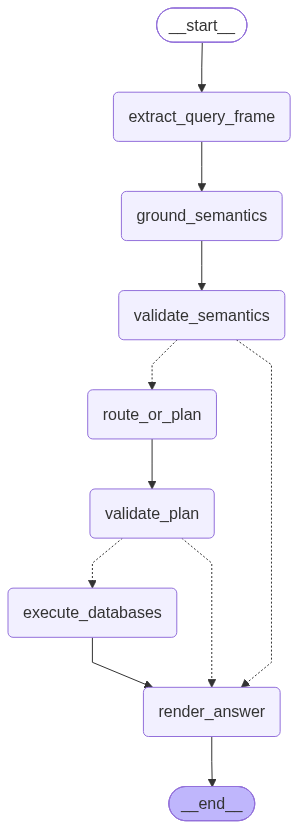

graph.png로 저장됨


In [ ]:
from IPython.display import Image, display,Markdown
from agent.agent_core import APP

# 컴파일된 LangGraph 가져오기
agent_graph = APP.get_graph()

# # Mermaid 그래프 정의 생성
# mermaid = agent_graph.draw_mermaid()


try:
    png_bytes = agent_graph.draw_mermaid_png()
    with open("graph.png", "wb") as f:
        f.write(png_bytes)
    display(Image(png_bytes))
    print("graph.png로 저장됨")
except Exception as e:
    print("PNG 렌더링 실패 (인터넷 연결 또는 방화벽 문제일 수 있음):", e)
    print("위쪽의 mermaid 텍스트나 draw_ascii() 결과를 대신 쓰시면 됩니다.")

# Stepwise Grounding v2

최종 노드 순서:

`extract_query_frame → ground_semantics → validate_semantics → route_or_plan → validate_plan → rdb_ground → example_retriever → generate_sql → validate_sql → execute_plan → verify_results → merge_evidence → render_answer`

Graph/Vector의 grounder는 `execute_plan`이 호출하는 **결정적 helper**로 둔다. 최종 LangGraph 노드 수는 위 13개로 고정한다.


## `src/tools/rdb_pipeline_v2.py` — RDB 물리 grounding / NL2SQL / AST validator


In [112]:
%%module tools.rdb_pipeline_v2 tools/rdb_pipeline_v2.py
# -*- coding: utf-8 -*-
"""RDB 물리 grounding → Gold example → HCX NL2SQL → AST/whitelist/dry-run.

중요한 경계:
- logical_plan은 binding id까지만 가진다.
- table/column 확정은 physical_ground()에서만 한다.
- HCX SQL은 절대 바로 실행하지 않는다.
"""
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any

import psycopg

import clova
from config import BOND_DSN, ROOT
from tools.schema_context import metadata, norm


SQL_DRAFT_SCHEMA = {
    "type": "object",
    "properties": {
        "sql": {"type": "string"},
        "params": {"type": "object"},
        "reason": {"type": "string"},
    },
    "required": ["sql", "params", "reason"],
}

SQL_SYSTEM = """
너는 PostgreSQL read-only NL2SQL 생성기다.
반드시 JSON 객체 하나만 출력한다.

규칙:
- SELECT 또는 WITH ... SELECT 하나만 생성
- 제공된 table/column whitelist 밖의 식별자 금지
- 제공된 joins 외 JOIN 금지
- 사용자 값은 SQL literal로 직접 넣지 말고 반드시 %(p0)s, %(p1)s 형태 named parameter 사용
- params 객체의 key는 placeholder와 정확히 일치
- INSERT/UPDATE/DELETE/MERGE/DDL/COPY/CALL 금지
- SELECT * 금지
- 질문/LogicalPlan에 없는 필터를 추가하지 말 것
- 기준일/cutoff을 임의로 바꾸지 말 것
"""


def _referenced_bindings(plan: dict) -> list[str]:
    ids = list(plan.get("select") or [])
    ids += [x.get("binding") for x in plan.get("filters") or [] if x.get("binding")]
    ids += [x.get("binding") for x in plan.get("order") or [] if x.get("binding")]
    ids += [x.get("binding") for x in plan.get("entities") or [] if x.get("binding")]
    return list(dict.fromkeys(x for x in ids if x))


def physical_ground(plan: dict) -> dict:
    """Logical binding을 실제 table/column으로 확정한다. 이 함수 이전에는 물리 컬럼을 확정하지 않는다."""
    if not plan.get("domain") or plan.get("unresolved"):
        raise ValueError(f"미해소 LogicalPlan: {plan.get('unresolved')}")

    schema, rules, bindings = metadata()
    domain = schema["domains"][plan["domain"]]
    binding_ids = _referenced_bindings(plan)
    unknown = sorted(set(binding_ids) - set(bindings))
    if unknown:
        raise ValueError(f"등록되지 않은 binding: {unknown}")

    physical = {}
    used_tables = set()
    for bid in binding_ids:
        b = bindings[bid]
        used_tables.add(b["table"])
        physical[bid] = {
            "binding": bid,
            "label": b.get("label"),
            "table": b["table"],
            "column": b["column"],
            "usage": list(b.get("usage") or []),
            "unit": b.get("unit"),
            "concept": b.get("concept") or b.get("ontology_concept") or bid,
            "business_rule": b.get("business_rule"),
            "sample_value": b.get("sample_value") or b.get("example"),
        }

    base = domain["base_table"]
    joins = []
    for table in sorted(used_tables - {base}):
        rule = next((j for j in schema.get("joins", []) if {j["left"], j["right"]} == {base, table}), None)
        if not rule:
            raise ValueError(f"허용되지 않은 JOIN: {base} ↔ {table}")
        joins.append(rule)

    columns_by_table = {}
    for item in physical.values():
        columns_by_table.setdefault(item["table"], set()).add(item["column"])

    required_filters = []
    if plan.get("as_of"):
        required_filters.append({"type": "as_of", **plan["as_of"]})

    return {
        "domain": plan["domain"],
        "base_table": base,
        "bindings": physical,
        "joins": joins,
        "whitelist": {
            "tables": sorted(used_tables),
            "columns_by_table": {k: sorted(v) for k, v in columns_by_table.items()},
        },
        "required_filters": required_filters,
        "max_rows": rules.get("max_rows"),
        "statement_timeout_ms": rules.get("statement_timeout_ms"),
    }


def _load_json_or_jsonl(path: Path) -> list[dict]:
    try:
        text = path.read_text(encoding="utf-8")
    except Exception:
        return []
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            return [x for x in obj if isinstance(x, dict)]
        if isinstance(obj, dict):
            for key in ("examples", "items", "data", "questions"):
                if isinstance(obj.get(key), list):
                    return [x for x in obj[key] if isinstance(x, dict)]
            return [obj]
    except Exception:
        pass
    rows = []
    for line in text.splitlines():
        try:
            x = json.loads(line)
            if isinstance(x, dict):
                rows.append(x)
        except Exception:
            continue
    return rows


def retrieve_gold_examples(question: str, domain: str | None, top_k: int = 3) -> list[dict]:
    """저장소의 gold/nl2sql JSON·JSONL 중 lexical 유사 예시를 찾는다. 파일이 없으면 []로 안전하게 통과."""
    paths = []
    for pattern in ("**/*nl2sql*.json", "**/*nl2sql*.jsonl", "**/*gold*.json", "**/*gold*.jsonl"):
        paths.extend(ROOT.glob(pattern))
    paths = [p for p in dict.fromkeys(paths) if ".git" not in p.parts][:40]

    qtokens = set(re.findall(r"[0-9A-Za-z가-힣]+", norm(question)))
    scored = []
    for path in paths:
        for row in _load_json_or_jsonl(path)[:1000]:
            row_domain = row.get("domain") or row.get("product_domain")
            if domain and row_domain and row_domain != domain:
                continue
            q = row.get("question") or row.get("nl") or row.get("query") or row.get("input") or ""
            sql = row.get("sql") or row.get("gold_sql") or row.get("answer_sql")
            if not q or not sql:
                continue
            tokens = set(re.findall(r"[0-9A-Za-z가-힣]+", norm(q)))
            score = len(qtokens & tokens) / max(1, len(qtokens | tokens))
            scored.append((score, {"question": q, "sql": sql, "source": str(path.relative_to(ROOT))}))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [dict(item, score=round(score, 4)) for score, item in scored[:top_k] if score > 0]


def generate_sql_draft(question: str, logical_plan: dict, rdb_context: dict, examples: list[dict]) -> dict:
    payload = {
        "question": question,
        "logical_plan": logical_plan,
        "physical_context": rdb_context,
        "gold_examples": examples,
    }
    text = clova.chat(
        "HCX-007",
        SQL_SYSTEM,
        json.dumps(payload, ensure_ascii=False, default=str),
        max_tokens=1800,
        response_format={"type": "json", "schema": SQL_DRAFT_SCHEMA},
        temperature=0.0,
    )
    out = clova.parse_json_loose(text)
    out["model"] = "HCX-007"
    out["revision"] = 0
    return out


def repair_sql_draft(question: str, logical_plan: dict, rdb_context: dict, examples: list[dict], draft: dict, errors: list[str]) -> dict:
    payload = {
        "question": question,
        "logical_plan": logical_plan,
        "physical_context": rdb_context,
        "gold_examples": examples,
        "previous_draft": draft,
        "validator_errors": errors,
        "instruction": "오류만 수정하고 새로운 조건/테이블/컬럼을 추가하지 말 것",
    }
    text = clova.chat(
        "HCX-007",
        SQL_SYSTEM,
        json.dumps(payload, ensure_ascii=False, default=str),
        max_tokens=1800,
        response_format={"type": "json", "schema": SQL_DRAFT_SCHEMA},
        temperature=0.0,
    )
    out = clova.parse_json_loose(text)
    out["model"] = "HCX-007"
    out["revision"] = 1
    return out


def _required_values(plan: dict) -> list[Any]:
    values = []
    for item in plan.get("entities") or []:
        if item.get("mode") == "exact":
            values.append(item.get("value"))
        elif item.get("mode") == "in":
            values.extend(item.get("values") or [])
    values.extend(x.get("value") for x in plan.get("filters") or [])
    return [x for x in values if x is not None]


def validate_sql_ast(draft: dict, logical_plan: dict, rdb_context: dict) -> dict:
    """sqlglot AST + whitelist + LogicalPlan 일치 여부를 검사한다."""
    errors = []
    sql_text = str(draft.get("sql") or "").strip().rstrip(";")
    params = draft.get("params") or {}
    if not isinstance(params, dict):
        return {"status": "FAIL", "errors": ["params가 object가 아님"]}
    if not sql_text:
        return {"status": "FAIL", "errors": ["SQL이 비어 있음"]}

    placeholder_names = re.findall(r"%\(([A-Za-z_][A-Za-z0-9_]*)\)s", sql_text)
    if sorted(set(placeholder_names)) != sorted(params):
        errors.append(f"placeholder/params 불일치: sql={sorted(set(placeholder_names))}, params={sorted(params)}")

    try:
        import sqlglot
        from sqlglot import exp
    except ImportError:
        return {"status": "FAIL", "errors": ["sqlglot 미설치: `%pip install sqlglot` 후 재실행"]}

    # psycopg named placeholder는 parser가 SQL 문법으로 보지 못하므로 AST 검사본에서 NULL로 치환한다.
    ast_sql = re.sub(r"%\([A-Za-z_][A-Za-z0-9_]*\)s", "NULL", sql_text)
    try:
        trees = sqlglot.parse(ast_sql, read="postgres")
    except Exception as exc:
        return {"status": "FAIL", "errors": [f"SQL parse 실패: {type(exc).__name__}: {exc}"]}
    if len(trees) != 1:
        errors.append("SQL statement는 정확히 1개여야 함")
        tree = trees[0] if trees else None
    else:
        tree = trees[0]
    if tree is None:
        return {"status": "FAIL", "errors": errors or ["AST 없음"]}

    forbidden = (exp.Insert, exp.Update, exp.Delete, exp.Create, exp.Drop, exp.Alter, exp.Merge, exp.Command)
    if any(tree.find(t) is not None for t in forbidden):
        errors.append("SELECT/WITH 외 statement 발견")
    if tree.find(exp.Select) is None:
        errors.append("SELECT가 없음")
    if tree.find(exp.Star) is not None:
        errors.append("SELECT * 금지")

    allowed_tables = set(rdb_context["whitelist"]["tables"])
    columns_by_table = {k: set(v) for k, v in rdb_context["whitelist"]["columns_by_table"].items()}
    aliases = {}
    seen_tables = set()
    for table in tree.find_all(exp.Table):
        full = f"{table.db}.{table.name}" if table.db else table.name
        matches = [x for x in allowed_tables if x == full or x.endswith("." + full) or x.rsplit(".", 1)[-1] == table.name]
        if len(matches) != 1:
            errors.append(f"whitelist 밖/모호한 table: {full}")
            continue
        canonical = matches[0]
        seen_tables.add(canonical)
        aliases[table.alias_or_name] = canonical
        aliases[table.name] = canonical
    if not seen_tables:
        errors.append("table 참조 없음")

    allowed_all_columns = set().union(*columns_by_table.values()) if columns_by_table else set()
    seen_columns = set()
    for col in tree.find_all(exp.Column):
        name = col.name
        seen_columns.add(name)
        if col.table:
            target = aliases.get(col.table)
            if not target:
                errors.append(f"알 수 없는 alias/table qualifier: {col.table}.{name}")
            elif name not in columns_by_table.get(target, set()):
                errors.append(f"whitelist 밖 column: {target}.{name}")
        elif name not in allowed_all_columns:
            errors.append(f"whitelist 밖 column: {name}")

    required_columns = {
        rdb_context["bindings"][bid]["column"]
        for bid in _referenced_bindings(logical_plan)
        if bid in rdb_context["bindings"]
    }
    missing_columns = sorted(required_columns - seen_columns)
    if missing_columns:
        errors.append(f"LogicalPlan 필수 column 누락: {missing_columns}")

    required_values = _required_values(logical_plan)
    param_values = list(params.values())
    for value in required_values:
        if value not in param_values:
            errors.append(f"LogicalPlan 값이 params에 없음: {value!r}")

    return {
        "status": "PASS" if not errors else "FAIL",
        "errors": errors,
        "tables": sorted(seen_tables),
        "columns": sorted(seen_columns),
        "placeholder_names": placeholder_names,
    }


def dry_run(draft: dict, timeout_ms: int | None = None) -> dict:
    """실행 전 PostgreSQL EXPLAIN. transaction은 read-only다."""
    sql_text = draft["sql"].strip().rstrip(";")
    params = draft.get("params") or {}
    try:
        with psycopg.connect(BOND_DSN, autocommit=False) as conn:
            with conn.transaction():
                conn.execute("SET TRANSACTION READ ONLY")
                if timeout_ms:
                    conn.execute(f"SET LOCAL statement_timeout = {int(timeout_ms)}")
                conn.execute("EXPLAIN (FORMAT JSON) " + sql_text, params).fetchone()
        return {"status": "PASS", "error": None}
    except Exception as exc:
        return {"status": "FAIL", "error": f"{type(exc).__name__}: {exc}"}


def execute_readonly(draft: dict, timeout_ms: int | None = None) -> dict:
    sql_text = draft["sql"].strip().rstrip(";")
    params = draft.get("params") or {}
    with psycopg.connect(BOND_DSN, autocommit=False) as conn:
        with conn.transaction():
            conn.execute("SET TRANSACTION READ ONLY")
            if timeout_ms:
                conn.execute(f"SET LOCAL statement_timeout = {int(timeout_ms)}")
            cur = conn.execute(sql_text, params)
            raw = cur.fetchall()
            columns = [d.name for d in cur.description]
    return {"status": "ok", "columns": columns, "rows": [dict(zip(columns, r)) for r in raw]}


registered: tools.rdb_pipeline_v2


In [113]:
# rdb_pipeline_v2 최소 자기검사 — DB/API 호출 없음
from tools import rdb_pipeline_v2 as RP

assert callable(RP.physical_ground)
assert callable(RP.validate_sql_ast)
assert callable(RP.dry_run)
print("PASS: rdb_pipeline_v2 함수 등록")


PASS: rdb_pipeline_v2 함수 등록


## `src/agent/nodes_v2.py` — 최종 13개 노드


In [114]:
%%module agent.nodes_v2 agent/nodes_v2.py
# -*- coding: utf-8 -*-
"""최종안 Stepwise Grounding 13-node pipeline."""
from __future__ import annotations

import copy
from datetime import date

import clova
from agent import nodes as legacy
from tools import data_api, graph
from tools import rdb_pipeline_v2 as rp

DATA_CUTOFF = legacy.DATA_CUTOFF
MAX_PLAN_STEPS = legacy.MAX_PLAN_STEPS
GRAPH_OPERATIONS = legacy.GRAPH_OPERATIONS


def _trace(state: dict, msg: str):
    return [*(state.get("trace") or []), msg]


def _abstain(code: str, reason: str, evidence=None):
    return {"code": code, "reason": reason, "evidence": evidence or []}


def _has_engine(state: dict, engine: str) -> bool:
    plan = state.get("validated_plan") or state.get("execution_plan") or {}
    return any(x.get("engine") == engine for x in plan.get("steps") or [])


# ①~④는 검증된 기존 구현 재사용
extract_query_frame = legacy.extract_query_frame
ground_semantics = legacy.ground_semantics
validate_semantics = legacy.validate_semantics
route_or_plan = legacy.route_or_plan


# ⑤ validate_plan — capability/의존성/경로/cutoff만 검증. RDB compile 금지.
def _plan_errors(state: dict) -> list[str]:
    plan = state.get("execution_plan") or {}
    steps = plan.get("steps")
    errors = []
    if not isinstance(steps, list):
        return ["steps가 list가 아님"]
    if len(steps) > MAX_PLAN_STEPS:
        errors.append(f"실행 단계가 {MAX_PLAN_STEPS}개 초과")

    seen, engines = [], []
    entity_values = {x.get("text") for x in state.get("intent", {}).get("entities") or []}
    for step in steps:
        sid, engine = step.get("id"), step.get("engine")
        op = step.get("operation")
        deps = step.get("depends_on") or []
        params = step.get("params") or {}
        if not sid or sid in seen:
            errors.append(f"step id 누락/중복: {sid}")
        if any(d not in seen for d in deps):
            errors.append(f"{sid}: depends_on은 앞 단계만 참조")
        seen.append(sid); engines.append(engine)

        if engine == "rdb":
            if op != "execute_logical_plan":
                errors.append(f"{sid}: 허용되지 않은 RDB operation={op}")
            # 중요: 여기서 rdb.compile_plan() 호출하지 않는다.
        elif engine == "graph":
            required = GRAPH_OPERATIONS.get(op)
            if required is None:
                errors.append(f"{sid}: 허용되지 않은 Graph operation={op}")
            elif not required <= set(params):
                errors.append(f"{sid}: Graph parameter 누락={sorted(required-set(params))}")
            else:
                invented = [v for k, v in params.items() if k != "limit" and v not in entity_values]
                if invented:
                    errors.append(f"{sid}: 질문에 없는 엔티티={invented}")
        elif engine == "vector":
            if op != "semantic_search":
                errors.append(f"{sid}: 허용되지 않은 Vector operation={op}")
            top_k = params.get("top_k", 3)
            if not isinstance(top_k, int) or not 1 <= top_k <= 10:
                errors.append(f"{sid}: top_k는 1~10")
        else:
            errors.append(f"{sid}: 허용되지 않은 engine={engine}")

        try:
            if date.fromisoformat(step.get("cutoff", "")) > date.fromisoformat(DATA_CUTOFF):
                errors.append(f"{sid}: cutoff 초과")
        except ValueError:
            errors.append(f"{sid}: cutoff 형식 오류")

    expected = {
        ("rdb",): "rdb_only", ("graph",): "graph_only", ("vector",): "vector_only",
        ("graph", "rdb"): "graph_then_rdb", ("graph", "vector"): "graph_then_vector",
        ("graph", "rdb", "vector"): "graph_then_rdb_vector",
    }.get(tuple(engines))
    if steps and plan.get("query_type") != expected:
        errors.append(f"query_type/engine 순서 불일치: {plan.get('query_type')} vs {engines}")
    if plan.get("query_type") == "unsupported":
        errors.append(plan.get("reason") or "지원 경로 없음")
    return errors


def validate_plan(state: dict) -> dict:
    errors = _plan_errors(state)
    if state.get("abstain"):
        errors.append("semantic validation이 이미 ABSTAIN")
    if errors:
        abstain = state.get("abstain") or _abstain("ABSTAIN_INVALID_PLAN", "; ".join(errors))
        return {"validated_plan": None, "plan_validation": {"status":"ABSTAIN","errors":errors},
                "abstain": abstain, "trace": _trace(state, "05 validate_plan: ABSTAIN")}
    return {"validated_plan": copy.deepcopy(state["execution_plan"]),
            "plan_validation": {"status":"PASS","errors":[]}, "abstain": None,
            "trace": _trace(state, "05 validate_plan: PASS (physical schema 미확정)")}


# ⑥ rdb_ground — 여기서 처음 table/column 확정
def rdb_ground(state: dict) -> dict:
    if state.get("abstain") or not _has_engine(state, "rdb"):
        return {"rdb_context": {"status":"skipped"}, "trace": _trace(state, "06 rdb_ground: skipped")}
    try:
        ctx = rp.physical_ground(state["semantics"]["logical_plan"])
        ctx["status"] = "PASS"
        return {"rdb_context": ctx,
                "trace": _trace(state, f"06 rdb_ground: PASS bindings={len(ctx['bindings'])} tables={len(ctx['whitelist']['tables'])}")}
    except Exception as exc:
        abstain = _abstain("ABSTAIN_RDB_GROUNDING_FAILED", f"RDB 물리 grounding 실패: {type(exc).__name__}: {exc}")
        return {"rdb_context":{"status":"FAIL"}, "abstain":abstain,
                "trace":_trace(state,"06 rdb_ground: FAIL")}


# ⑦ example_retriever
def example_retriever(state: dict) -> dict:
    if state.get("abstain") or not _has_engine(state, "rdb"):
        return {"sql_examples": [], "trace": _trace(state, "07 example_retriever: skipped")}
    examples = rp.retrieve_gold_examples(state["question"], state["semantics"].get("domain"), top_k=3)
    return {"sql_examples": examples,
            "trace": _trace(state, f"07 example_retriever: {len(examples)} examples")}


# ⑧ generate_sql — HCX 초안만 생성, 실행 금지
def generate_sql(state: dict) -> dict:
    if state.get("abstain") or not _has_engine(state, "rdb"):
        return {"sql_draft": {"status":"skipped"}, "trace": _trace(state,"08 generate_sql: skipped")}
    try:
        draft = rp.generate_sql_draft(state["question"], state["semantics"]["logical_plan"],
                                      state["rdb_context"], state.get("sql_examples") or [])
        draft["status"] = "generated"
        return {"sql_draft": draft, "trace": _trace(state,"08 generate_sql: HCX-007 draft generated")}
    except Exception as exc:
        abstain = _abstain("ABSTAIN_SQL_GENERATION_FAILED", f"SQL 생성 실패: {type(exc).__name__}: {exc}")
        return {"sql_draft":{"status":"FAIL"}, "abstain":abstain,
                "trace":_trace(state,"08 generate_sql: FAIL")}


# ⑨ validate_sql — AST + whitelist + QueryFrame/LogicalPlan + dry-run + 최대 1회 repair
def _check_sql(state: dict, draft: dict) -> dict:
    ast = rp.validate_sql_ast(draft, state["semantics"]["logical_plan"], state["rdb_context"])
    dry = {"status":"SKIP", "error":None}
    errors = list(ast.get("errors") or [])
    if ast.get("status") == "PASS":
        dry = rp.dry_run(draft, timeout_ms=state["rdb_context"].get("statement_timeout_ms"))
        if dry["status"] != "PASS":
            errors.append("DB dry-run 실패: " + str(dry.get("error")))
    return {"status":"PASS" if not errors else "FAIL", "ast":ast, "dry_run":dry, "errors":errors}


def validate_sql(state: dict) -> dict:
    if state.get("abstain") or not _has_engine(state, "rdb"):
        return {"sql_validation":{"status":"skipped"}, "validated_sql":None,
                "trace":_trace(state,"09 validate_sql: skipped")}
    draft = state["sql_draft"]
    first = _check_sql(state, draft)
    attempts = [{"revision": draft.get("revision",0), **first}]
    if first["status"] == "PASS":
        return {"validated_sql":draft, "sql_validation":{"status":"PASS","attempts":attempts},
                "trace":_trace(state,"09 validate_sql: PASS revision=0")}

    # 정확히 최대 1회만 수정
    try:
        repaired = rp.repair_sql_draft(state["question"], state["semantics"]["logical_plan"],
                                       state["rdb_context"], state.get("sql_examples") or [], draft, first["errors"])
        repaired["status"] = "generated"
        second = _check_sql(state, repaired)
        attempts.append({"revision":1, **second})
    except Exception as exc:
        second = {"status":"FAIL","errors":[f"repair 실패: {type(exc).__name__}: {exc}"]}
        repaired = None
        attempts.append({"revision":1, **second})

    if second["status"] == "PASS":
        return {"validated_sql":repaired, "sql_draft":repaired,
                "sql_validation":{"status":"PASS","attempts":attempts},
                "trace":_trace(state,"09 validate_sql: PASS revision=1")}
    abstain = _abstain("ABSTAIN_INVALID_SQL", "; ".join(second.get("errors") or first["errors"]))
    return {"validated_sql":None, "sql_validation":{"status":"ABSTAIN","attempts":attempts},
            "abstain":abstain, "trace":_trace(state,"09 validate_sql: ABSTAIN after 1 repair")}


# Graph/Vector grounder는 execute_plan에서 호출하지만 각각 독립 함수라 직접 단위테스트 가능.
def graph_ground(step: dict) -> dict:
    op = step.get("operation")
    required = GRAPH_OPERATIONS.get(op)
    params = step.get("params") or {}
    if required is None or not required <= set(params):
        raise ValueError(f"허용되지 않은 Graph path: {op}, params={params}")
    return {"operation":op, "params":params, "cutoff":step.get("cutoff")}


def vector_ground(state: dict, step: dict, prior_outputs: dict) -> dict:
    params = dict(step.get("params") or {})
    entity_ids = []
    for result in prior_outputs.values():
        for row in result.get("rows") or result.get("results") or []:
            pid = row.get("product_id") or row.get("productId")
            if pid is not None:
                entity_ids.append(pid)
    return {"query":state["question"], "top_k":params.get("top_k",3),
            "product_ids":list(dict.fromkeys(entity_ids)), "cutoff":step.get("cutoff")}


# ⑩ execute_plan
def execute_plan(state: dict) -> dict:
    if state.get("abstain") or not state.get("validated_plan"):
        return {"execution":{"status":"skipped","steps":{}}, "trace":_trace(state,"10 execute_plan: skipped")}
    outputs = {}
    try:
        for step in state["validated_plan"]["steps"]:
            engine = step["engine"]
            if engine == "rdb":
                if not state.get("validated_sql"):
                    raise ValueError("validated_sql 없음")
                result = rp.execute_readonly(state["validated_sql"], timeout_ms=state["rdb_context"].get("statement_timeout_ms"))
            elif engine == "graph":
                grounded = graph_ground(step)
                fn = getattr(graph, grounded["operation"], None)
                if fn is None:
                    raise ValueError(f"Graph dispatcher에 함수 없음: {grounded['operation']}")
                result = fn(**grounded["params"])
            elif engine == "vector":
                grounded = vector_ground(state, step, outputs)
                qv = clova.embed(grounded["query"])
                result = data_api.FinancialDataClient.from_env().semantic_search(qv, top_k=grounded["top_k"])
                # 현재 data_api가 product_id pre-filter를 지원하지 않으므로 결과에서 entity scope를 엄격히 적용.
                if grounded["product_ids"] and result.get("results"):
                    allowed = set(grounded["product_ids"])
                    result["results"] = [x for x in result["results"] if x.get("product_id") in allowed]
                    result["entity_scope"] = grounded["product_ids"]
            else:
                raise ValueError(f"unknown engine={engine}")
            outputs[step["id"]] = result
        return {"execution":{"status":"ok","steps":outputs},
                "trace":_trace(state,f"10 execute_plan: PASS steps={len(outputs)}")}
    except Exception as exc:
        abstain = _abstain("ABSTAIN_EXECUTION_FAILED", f"DB 실행 실패: {type(exc).__name__}: {exc}")
        return {"execution":{"status":"error","steps":outputs}, "abstain":abstain,
                "trace":_trace(state,"10 execute_plan: FAIL")}


# ⑪ verify_results
def verify_results(state: dict) -> dict:
    if state.get("abstain"):
        return {"result_verification":{"status":"skipped"}, "trace":_trace(state,"11 verify_results: skipped")}
    execution = state.get("execution") or {}
    checks, failures = [], []
    for step in (state.get("validated_plan") or {}).get("steps") or []:
        result = (execution.get("steps") or {}).get(step["id"], {})
        rows = result.get("rows") if isinstance(result, dict) else None
        if rows is None and isinstance(result, dict):
            rows = result.get("results")
        rows = rows or []
        check = {"step_id":step["id"], "engine":step["engine"], "row_count":len(rows),
                 "cutoff_ok": step.get("cutoff") <= DATA_CUTOFF,
                 "empty_kind":"matched_zero" if len(rows)==0 else None}
        if result.get("status") == "pending":
            check["empty_kind"] = "data_not_loaded"
        if not check["cutoff_ok"]:
            failures.append(f"{step['id']}: cutoff 위반")
        checks.append(check)
    status = "PASS" if not failures else "FAIL"
    if failures:
        abstain = _abstain("ABSTAIN_RESULT_VERIFICATION_FAILED", "; ".join(failures))
        return {"result_verification":{"status":status,"checks":checks,"errors":failures},
                "abstain":abstain,"trace":_trace(state,"11 verify_results: FAIL")}
    return {"result_verification":{"status":status,"checks":checks,"errors":[]},
            "trace":_trace(state,"11 verify_results: PASS")}


# ⑫ merge_evidence
def merge_evidence(state: dict) -> dict:
    if state.get("abstain"):
        return {"evidence":[], "evidence_package":{"status":"skipped","items":[]},
                "trace":_trace(state,"12 merge_evidence: skipped")}
    items = []
    execution = state.get("execution") or {}
    for step in (state.get("validated_plan") or {}).get("steps") or []:
        result = (execution.get("steps") or {}).get(step["id"], {})
        if step["engine"] == "rdb":
            for bid in state.get("semantics",{}).get("logical_plan",{}).get("select") or []:
                b = state.get("rdb_context",{}).get("bindings",{}).get(bid)
                if b:
                    items.append({"engine":"rdb","binding":bid,"label":b.get("label"),
                                  "source_table":b["table"],"source_column":b["column"],
                                  "as_of":state["semantics"]["logical_plan"].get("as_of")})
            for row in result.get("rows") or []:
                items.append({"engine":"rdb","row":row})
        elif step["engine"] == "graph":
            for row in result.get("rows") or []:
                items.append({"engine":"graph","row":row,"cutoff":step.get("cutoff")})
        elif step["engine"] == "vector":
            for hit in result.get("results") or []:
                items.append({"engine":"vector", **hit})
    return {"evidence":items, "evidence_package":{"status":"PASS","items":items},
            "trace":_trace(state,f"12 merge_evidence: {len(items)} items")}


# ⑬ render_answer — HCX-005, evidence 밖 내용 금지
ANSWER_SYSTEM = """
너는 금융상품 질의응답 renderer다.
입력된 evidence_package에 명시된 사실만 사용한다.
근거에 없는 사실은 추론하거나 일반지식으로 보충하지 말고 '확인할 수 없음'이라고 쓴다.
수치/상품명/관계는 evidence와 정확히 일치해야 한다.
"""

def render_answer(state: dict) -> dict:
    if state.get("abstain"):
        return {"answer":f"확인할 수 없음: {state['abstain']['reason']}",
                "trace":_trace(state,"13 render_answer: ABSTAIN")}
    package = state.get("evidence_package") or {"items":[]}
    if not package.get("items"):
        return {"answer":"주어진 조건과 완전일치하는 근거를 확인할 수 없습니다.",
                "trace":_trace(state,"13 render_answer: empty evidence")}
    try:
        import json
        user = json.dumps({"question":state["question"],"evidence_package":package}, ensure_ascii=False, default=str)
        answer = clova.chat("HCX-005", ANSWER_SYSTEM, user, max_tokens=1200, temperature=0.0)
    except Exception as exc:
        answer = f"확인할 수 없음: 답변 생성 실패 ({type(exc).__name__})"
    return {"answer":answer, "trace":_trace(state,"13 render_answer: done")}


NODE_SEQUENCE = (
    extract_query_frame, ground_semantics, validate_semantics, route_or_plan, validate_plan,
    rdb_ground, example_retriever, generate_sql, validate_sql, execute_plan,
    verify_results, merge_evidence, render_answer,
)
NODE_NAMES = tuple(fn.__name__ for fn in NODE_SEQUENCE)


def apply_node(state: dict, node) -> dict:
    out = dict(state); out.update(node(out)); return out


registered: agent.nodes_v2


In [115]:
# 노드 이름/순서 정적검사 — 외부 API/DB 호출 없음
from agent import nodes_v2 as N2

EXPECTED = (
    "extract_query_frame", "ground_semantics", "validate_semantics", "route_or_plan", "validate_plan",
    "rdb_ground", "example_retriever", "generate_sql", "validate_sql", "execute_plan",
    "verify_results", "merge_evidence", "render_answer",
)
assert N2.NODE_NAMES == EXPECTED
assert "compile_plan" not in N2.validate_plan.__code__.co_names
print("PASS: 최종 13개 노드 순서 / validate_plan 물리 compile 분리")


PASS: 최종 13개 노드 순서 / validate_plan 물리 compile 분리


## `src/agent/agent_core_v2.py` — LangGraph 연결


In [116]:
%%module agent.agent_core_v2 agent/agent_core_v2.py
# -*- coding: utf-8 -*-
from __future__ import annotations
from typing import TypedDict

from langgraph.graph import END, START, StateGraph
from agent import nodes_v2 as N


class PipelineState(TypedDict, total=False):
    question_id: str
    question: str
    planner_mode: str
    use_schema_vector: bool
    intent: dict
    semantics: dict
    metadata_context: dict
    semantic_validation: dict
    execution_plan: dict
    validated_plan: dict | None
    plan_validation: dict
    rdb_context: dict
    sql_examples: list
    sql_draft: dict
    validated_sql: dict | None
    sql_validation: dict
    execution: dict
    result_verification: dict
    evidence_package: dict
    evidence: list
    abstain: dict | None
    trace: list[str]
    answer: str


def initial_state(question: str, question_id: str = "", planner_mode: str = "auto", use_schema_vector: bool = True):
    return {
        "question_id":question_id, "question":question, "planner_mode":planner_mode,
        "use_schema_vector":use_schema_vector, "intent":{}, "semantics":{}, "metadata_context":{},
        "semantic_validation":{}, "execution_plan":{}, "validated_plan":None, "plan_validation":{},
        "rdb_context":{}, "sql_examples":[], "sql_draft":{}, "validated_sql":None,
        "sql_validation":{}, "execution":{}, "result_verification":{}, "evidence_package":{},
        "evidence":[], "abstain":None, "trace":[], "answer":"",
    }


def _next_or_render(state: PipelineState, next_node: str) -> str:
    return "render_answer" if state.get("abstain") else next_node


def build():
    g = StateGraph(PipelineState)
    for fn in N.NODE_SEQUENCE:
        g.add_node(fn.__name__, fn)
    g.add_edge(START, "extract_query_frame")
    g.add_edge("extract_query_frame", "ground_semantics")
    g.add_edge("ground_semantics", "validate_semantics")
    g.add_conditional_edges("validate_semantics", lambda s:_next_or_render(s,"route_or_plan"),
                            {"route_or_plan":"route_or_plan","render_answer":"render_answer"})
    g.add_edge("route_or_plan", "validate_plan")
    g.add_conditional_edges("validate_plan", lambda s:_next_or_render(s,"rdb_ground"),
                            {"rdb_ground":"rdb_ground","render_answer":"render_answer"})
    g.add_edge("rdb_ground", "example_retriever")
    g.add_edge("example_retriever", "generate_sql")
    g.add_conditional_edges("generate_sql", lambda s:_next_or_render(s,"validate_sql"),
                            {"validate_sql":"validate_sql","render_answer":"render_answer"})
    g.add_conditional_edges("validate_sql", lambda s:_next_or_render(s,"execute_plan"),
                            {"execute_plan":"execute_plan","render_answer":"render_answer"})
    g.add_conditional_edges("execute_plan", lambda s:_next_or_render(s,"verify_results"),
                            {"verify_results":"verify_results","render_answer":"render_answer"})
    g.add_conditional_edges("verify_results", lambda s:_next_or_render(s,"merge_evidence"),
                            {"merge_evidence":"merge_evidence","render_answer":"render_answer"})
    g.add_edge("merge_evidence", "render_answer")
    g.add_edge("render_answer", END)
    return g.compile()

APP = build()


def to_response(state: PipelineState):
    return {
        "question_id":state.get("question_id", ""), "question":state["question"],
        "retrieved_context":state.get("evidence") or [], "think_trace":state.get("trace") or [],
        "answer":state.get("answer", ""), "abstain":state.get("abstain"),
        "node_outputs":{
            "01_query_frame":state.get("intent"), "02_semantics":state.get("semantics"),
            "03_semantic_validation":state.get("semantic_validation"),
            "04_execution_plan":state.get("execution_plan"), "05_plan_validation":state.get("plan_validation"),
            "06_rdb_ground":state.get("rdb_context"), "07_examples":state.get("sql_examples"),
            "08_sql_draft":state.get("sql_draft"), "09_sql_validation":state.get("sql_validation"),
            "10_execution":state.get("execution"), "11_result_verification":state.get("result_verification"),
            "12_evidence_package":state.get("evidence_package"),
        },
    }


def ask(question: str, question_id: str = "", planner_mode: str = "auto", use_schema_vector: bool = True):
    state = initial_state(question, question_id, planner_mode, use_schema_vector)
    return to_response(APP.invoke(state))


registered: agent.agent_core_v2


In [117]:
# 그래프 등록 정적검사
from agent.agent_core_v2 import APP, initial_state
from agent.nodes_v2 import NODE_NAMES
assert len(NODE_NAMES) == 13
print("PASS: agent_core_v2 compiled / 13 nodes")


PASS: agent_core_v2 compiled / 13 nodes


# 노드별 단계 테스트

원칙: **한 노드를 추가/수정하면 바로 아래 해당 테스트 셀까지만 실행**한다.  
`state.update(out)` 방식이라 어느 단계에서 상태가 깨졌는지 바로 확인할 수 있다.

처음 테스트할 때는 아래 초기화 셀을 실행한 뒤 ①부터 순서대로 내려간다.


In [118]:
from agent import nodes_v2 as N
from agent.agent_core_v2 import initial_state

TEST_QUESTION = "현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만기구분, 듀레이션을 알려줘. 원본 등급값과 온톨로지 분류값을 함께 제시해줘"
TEST_QUESTION = "VOO의 정식 상품명과 총보수를 알려줘"
state = initial_state(TEST_QUESTION, question_id="step-test", planner_mode="auto", use_schema_vector=True)
print("state initialized")


state initialized


### ① extract_query_frame


In [119]:
out = N.extract_query_frame(state); state.update(out)
state["intent"]


{'domain_candidates': ['etf_gl'],
 'task': 'lookup',
 'targets': [],
 'entities': [{'text': 'VOO', 'role': 'ticker', 'match_mode': 'exact'}],
 'requested_fields': [{'text': '정식 상품명'}, {'text': '총보수'}],
 'constraints': [],
 'relations': [],
 'ordering': [],
 'limit': None,
 'temporal': {'kind': 'latest_snapshot',
  'raw': None,
  'as_of_text': None,
  'window_text': None},
 'computation': [],
 'evidence_requirements': [],
 'ambiguity': [],
 'validation_targets': [],
 '_guard': [],
 '_raw': {'domain_candidates': ['etf_gl'],
  'task': 'lookup',
  'targets': [],
  'entities': [{'text': 'VOO', 'role': 'ticker', 'match_mode': 'exact'}],
  'requested_fields': [{'text': '정식 상품명'}, {'text': '총보수'}],
  'constraints': [],
  'relations': [],
  'ordering': [],
  'limit': None,
  'temporal': {'kind': 'latest_snapshot',
   'raw': None,
   'as_of_text': None,
   'window_text': None},
  'computation': [],
  'evidence_requirements': [],
  'ambiguity': [],
  'validation_targets': []}}

### ② ground_semantics


In [70]:
out = N.ground_semantics(state); state.update(out)
state["semantics"]

{'domain': 'etf_gl',
 'concepts': ['fp:productCode',
  'fp:productName',
  'fp:expenseRatio',
  'fp:productGroup'],
 'entities': [{'text': 'VOO', 'role': 'ticker', 'match_mode': 'exact'}],
 'entity_checks': [{'text': 'VOO',
   'role': 'ticker',
   'entity_type': 'product',
   'status': 'ok',
   'rows': [{'product': 'http://mafest.ai/instance/etfgl-VOO',
     'name': 'Vanguard 500 Index Fund;ETF',
     'code': 'VOO',
     'region_label': '미국'}]}],
 'relations': [],
 'taxonomy_constraints': [],
 'schema_vector_hits': [],
 'logical_plan': {'domain': 'etf_gl',
  'task': 'lookup',
  'entities': [{'mode': 'exact', 'binding': 'etf_gl.ticker', 'value': 'VOO'}],
  'select': ['etf_gl.product_code',
   'etf_gl.product_name',
   'etf_gl.expense_ratio'],
  'filters': [{'binding': 'etf_gl.group', 'operator': '==', 'value': 'ETF'}],
  'order': [],
  'limit': None,
  'unresolved': [],
  'concepts': ['fp:productCode',
   'fp:productName',
   'fp:expenseRatio',
   'fp:productGroup'],
  'as_of': {'value'

### ③ validate_semantics


In [71]:
out = N.validate_semantics(state); state.update(out)
state["semantic_validation"]

{'status': 'PASS', 'abstain': None}

### ④ route_or_plan


In [72]:
out = N.route_or_plan(state); state.update(out)
state["execution_plan"]

{'query_type': 'rdb_only',
 'steps': [{'id': 'R1',
   'engine': 'rdb',
   'operation': 'execute_logical_plan',
   'depends_on': [],
   'params': {},
   'cutoff': '2026-08-24'}],
 'reason': '단일 도메인의 검증된 LogicalPlan',
 'planner': 'deterministic'}

### ⑤ validate_plan


In [73]:
out = N.validate_plan(state); state.update(out)
assert "compile_plan" not in N.validate_plan.__code__.co_names
assert state["plan_validation"]["status"] in {"PASS","ABSTAIN"}
state["plan_validation"]

{'status': 'PASS', 'errors': []}

### ⑥ rdb_ground


In [74]:
out = N.rdb_ground(state); state.update(out)
if state.get("abstain") is None and state["rdb_context"].get("status") != "skipped":
    assert state["rdb_context"]["bindings"]
    assert state["rdb_context"]["whitelist"]["tables"]
state["rdb_context"]


{'domain': 'etf_gl',
 'base_table': 'raw.etf_gl_master',
 'bindings': {'etf_gl.product_code': {'binding': 'etf_gl.product_code',
   'label': '상품번호',
   'table': 'raw.etf_gl_master',
   'column': 'pd_itm_no',
   'usage': ['select', 'filter', 'sort'],
   'unit': None,
   'concept': 'etf_gl.product_code',
   'business_rule': None,
   'sample_value': None},
  'etf_gl.product_name': {'binding': 'etf_gl.product_name',
   'label': '정식 상품명',
   'table': 'raw.etf_gl_master',
   'column': 'pd_nm',
   'usage': ['select', 'filter'],
   'unit': None,
   'concept': 'etf_gl.product_name',
   'business_rule': None,
   'sample_value': None},
  'etf_gl.expense_ratio': {'binding': 'etf_gl.expense_ratio',
   'label': '총보수',
   'table': 'raw.etf_gl_master',
   'column': 'cu_charge_rt',
   'usage': ['select', 'filter', 'sort'],
   'unit': '%',
   'concept': 'etf_gl.expense_ratio',
   'business_rule': None,
   'sample_value': None},
  'etf_gl.group': {'binding': 'etf_gl.group',
   'label': '상품군',
   'table':

### ⑦ example_retriever


In [75]:
out = N.example_retriever(state); state.update(out)
state["sql_examples"]

[]

### ⑧ generate_sql


In [76]:
out = N.generate_sql(state); state.update(out)
state["sql_draft"]

{'sql': "SELECT pd_itm_no AS etf_gl.product_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_master WHERE pd_abrv_nm = %(etf_gl.ticker)s AND pd_grp_no = 'ETF' AND du_clpr_base_dt IN (SELECT MAX(du_clpr_base_dt) FROM raw.etf_gl_master WHERE pd_abrv_nm = %(etf_gl.ticker)s)",
 'params': {'etf_gl.ticker': 'VOO'},
 'reason': 'VOO의 정식 상품명과 총보수를 조회하기 위해 티커를 사용하여 해당 정보를 가져옵니다.',
 'model': 'HCX-007',
 'revision': 0,
 'status': 'generated'}

### ⑨ validate_sql


In [77]:
out = N.validate_sql(state); state.update(out)
# PASS라면 AST와 DB dry-run을 둘 다 통과해야 한다. 실패 시 HCX repair는 최대 1회만 존재한다.
if state["sql_validation"].get("status") == "PASS":
    last = state["sql_validation"]["attempts"][-1]
    assert last["ast"]["status"] == "PASS" and last["dry_run"]["status"] == "PASS"
assert len(state["sql_validation"].get("attempts", [])) <= 2
state["sql_validation"]

{'status': 'ABSTAIN',
 'attempts': [{'revision': 0,
   'status': 'FAIL',
   'ast': {'status': 'FAIL',
    'errors': ['SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.\n  SELECT pd_itm_no AS etf_gl\x1b.\x1bproduct_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_mas']},
   'dry_run': {'status': 'SKIP', 'error': None},
   'errors': ['SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.\n  SELECT pd_itm_no AS etf_gl\x1b.\x1bproduct_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_mas']},
  {'revision': 1,
   'status': 'FAIL',
   'ast': {'status': 'FAIL',
    'errors': ['SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.\n  SELECT pd_itm_no AS etf_gl\x1b.\x1bproduct_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_mas']},
   'dry_run': {'status': 'SKIP', 'error': None},
   'errors

### ⑩ execute_plan


In [78]:
out = N.execute_plan(state); state.update(out)
state["execution"]

{'status': 'skipped', 'steps': {}}

### ⑪ verify_results


In [79]:
out = N.verify_results(state); state.update(out)
state["result_verification"]

{'status': 'skipped'}

### ⑫ merge_evidence


In [80]:
out = N.merge_evidence(state); state.update(out)
state["evidence_package"]


{'status': 'skipped', 'items': []}

### ⑬ render_answer


In [81]:
out = N.render_answer(state); state.update(out)
print(state["answer"])


확인할 수 없음: SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.
  SELECT pd_itm_no AS etf_gl.product_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_mas


## Graph / Vector grounder 단위테스트


In [82]:
# 실제 DB 실행 없이 helper contract만 확인
sample_g = {"operation":"company_info", "params":{"name":"에코프로"}, "cutoff":"2026-08-24"}
assert N.graph_ground(sample_g)["operation"] == "company_info"

sample_v = {"params":{"top_k":3}, "cutoff":"2026-08-24"}
vg = N.vector_ground({"question":"상품 설명",}, sample_v, {})
assert vg["top_k"] == 3 and vg["product_ids"] == []
print("PASS: graph_ground / vector_ground contracts")


PASS: graph_ground / vector_ground contracts


## 전체 E2E — 새 그래프


In [120]:
from agent.agent_core_v2 import ask

result = ask(TEST_QUESTION, question_id="e2e-v2")
result


{'question_id': 'e2e-v2',
 'question': 'VOO의 정식 상품명과 총보수를 알려줘',
 'retrieved_context': [],
 'think_trace': ["01 extract_query_frame: task=lookup domains=['etf_gl'] entities=1 constraints=0",
  '02 ground_semantics: domain=etf_gl concepts=4 unresolved=0',
  '03 validate_semantics: PASS',
  '04 route_or_plan: type=rdb_only steps=1 planner=deterministic',
  '05 validate_plan: PASS (physical schema 미확정)',
  '06 rdb_ground: PASS bindings=5 tables=1',
  '07 example_retriever: 0 examples',
  '08 generate_sql: HCX-007 draft generated',
  '09 validate_sql: ABSTAIN after 1 repair',
  '13 render_answer: ABSTAIN'],
 'answer': '확인할 수 없음: SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.\n  SELECT pd_itm_no AS etf_gl\x1b.\x1bproduct_code, pd_nm AS etf_gl.product_name, cu_charge_rt AS etf_gl.expense_ratio FROM raw.etf_gl_mas',
 'abstain': {'code': 'ABSTAIN_INVALID_SQL',
  'reason': 'SQL parse 실패: ParseError: Invalid expression / Unexpected token. Line 1, Col: 27.\n  SEL

## `.py` 반영 순서

노트북 단계 테스트가 모두 통과한 뒤에만 기존 `sync_to_py()`를 사용한다.

새 파일은 다음 두 개가 추가된다.

- `src/tools/rdb_pipeline_v2.py`
- `src/agent/nodes_v2.py`
- `src/agent/agent_core_v2.py`

초기에는 기존 `agent.nodes`, `agent.agent_core`를 덮어쓰지 않으므로 A/B 비교가 가능하다. 최종 채택 후 이름을 교체하는 편이 안전하다.


## .py 반영

셀 수정 후 **노트북 저장(Ctrl+S)** → 아래 실행.

In [ ]:
# sync_to_py()                # diff 확인
# sync_to_py(dry_run=False)   # 실제 반영